# Project 1: LendingClub Interest rate Prediction

## Section 1 - Exploratory Data Analysis (EDA)

**Goal:** Load the dataset, understand its structure, identify the target variable,
explore feature distributions, and flag missing values for treatment.

**Team Member Responsibility:** Initial EDA, Missing Value Identification & Treatment, Train/Test Split, Target Identification

In [1]:
# ─────────────────────────────────────────────
# Step 1: Imports & Data Loading
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
#!pip install XGBoost


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
# Google Colab code necessary to upload file
#from google.colab import files

# Upload files from your computer into Colab
#uploaded = files.upload()

In [3]:
# Load the training dataset
df = pd.read_csv('LC_train.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 100,000 rows × 39 columns


### 1.1 Dataset Structure
First look at the data: shape, data types, and sample rows.

In [4]:
# ─────────────────────────────────────────────
# 1.1 Dataset Structure: Shape, Types & Preview
# ─────────────────────────────────────────────

# Preview the first 5 rows
print("=== First 5 Rows ===")
display(df.head())

# Data types and non-null counts
print("\n=== Data Types & Non-Null Counts ===")
print(df.info())

# Separate columns by type for reference
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features:     {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"\nNumeric:     {numeric_cols}")
print(f"Categorical: {categorical_cols}")

=== First 5 Rows ===


,addr_state,all_util,annual_inc,application_type,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,dti,emp_length,emp_title,fico_range_high,fico_range_low,home_ownership,inq_fi,inq_last_12m,loan_amnt,loan_status,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mort_acc,mths_since_last_record,mths_since_rcnt_il,mths_since_recent_bc,mths_since_recent_inq,open_acc,pub_rec,pub_rec_bankruptcies,purpose,revol_bal,revol_util,term,title,tot_coll_amt,tot_cur_bal,total_acc,total_bal_ex_mort,verification_status,zip_code,int_rate
0,TX,80.00,36000.00,Individual,0,0,0,26.33,NaN,NaN,674,670,OWN,2,5,5000,Current,57.00,35,0,NaN,12.00,23.00,0.00,5,0,0,other,16452,70.90,36 months,Other,0,34683.00,7,34683,Verified,780xx,18.62
1,RI,61.00,45000.00,Individual,0,0,0,38.51,1 year,Composite Boat Builder,734,730,RENT,1,1,15000,Current,113.00,103,0,NaN,17.00,1.00,0.00,14,0,0,debt_consolidation,15798,42.60,60 months,Debt consolidation,0,63873.00,18,63873,Not Verified,028xx,16.08
2,CA,31.00,53040.00,Individual,0,0,0,25.20,< 1 year,Fed-Ex Ground Driver,809,805,MORTGAGE,0,1,4550,Current,129.00,145,4,NaN,34.00,33.00,0.00,9,0,0,credit_card,4642,12.60,36 months,Credit card refinancing,0,333107.00,26,24452,Verified,920xx,7.56
3,NY,87.00,125000.00,Individual,0,0,0,27.87,10+ years,Financial Service Leader,684,680,MORTGAGE,1,0,4000,Issued,259.00,230,4,NaN,11.00,7.00,19.00,14,0,0,debt_consolidation,26848,93.20,36 months,Debt consolidation,0,342153.00,38,141033,Verified,124xx,17.30
4,PA,75.00,73000.00,Individual,0,0,0,35.12,10+ years,Environmental Scientist,759,755,MORTGAGE,1,0,15075,Current,163.00,126,1,NaN,6.00,24.00,13.00,19,0,0,debt_consolidation,10429,25.30,36 months,Debt consolidation,0,426837.00,36,160302,Not Verified,194xx,10.81



=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   addr_state                  100000 non-null  object 
 1   all_util                    99984 non-null   float64
 2   annual_inc                  100000 non-null  float64
 3   application_type            100000 non-null  object 
 4   chargeoff_within_12_mths    100000 non-null  int64  
 5   collections_12_mths_ex_med  100000 non-null  int64  
 6   delinq_2yrs                 100000 non-null  int64  
 7   dti                         99814 non-null   float64
 8   emp_length                  91331 non-null   object 
 9   emp_title                   85080 non-null   object 
 10  fico_range_high             100000 non-null  int64  
 11  fico_range_low              100000 non-null  int64  
 12  home_ownership              100000 

### 1.2 Target Variable: Interest Rate (`int_rate`)
The target variable is `int_rate`, representing the loan interest rate as a
percentage (0–100). This is a continuous regression problem.

=== Target Variable Summary ===
count   100000.00
mean        12.95
std          5.26
min          6.46
25%          8.19
50%         11.71
75%         16.12
max         30.99
Name: int_rate, dtype: float64

Missing values: 0


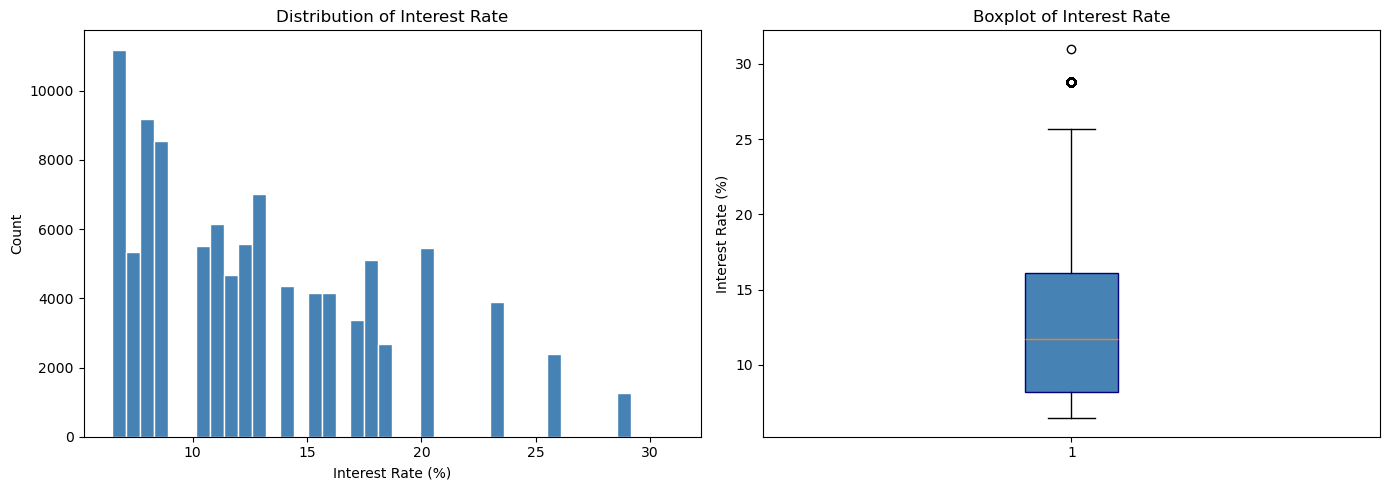


Target range: 6.46% – 30.99%
Mean: 12.95% | Median: 11.71%
Skewness: 0.8511


In [5]:
# ─────────────────────────────────────────────
# 1.2 Target Variable: int_rate
# ─────────────────────────────────────────────

target = 'int_rate'

print("=== Target Variable Summary ===")
print(df[target].describe())
print(f"\nMissing values: {df[target].isnull().sum()}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[target], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Interest Rate')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df[target].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Interest Rate')
axes[1].set_ylabel('Interest Rate (%)')

plt.tight_layout()
plt.show()

print(f"\nTarget range: {df[target].min():.2f}% – {df[target].max():.2f}%")
print(f"Mean: {df[target].mean():.2f}% | Median: {df[target].median():.2f}%")
print(f"Skewness: {df[target].skew():.4f}")

### Key Observations: Target Variable

- **Range:** Interest rates span **6.46% to 30.99%**, confirming all values fall within the required 0–100 submission range.
- **Distribution:** The histogram shows a **right-skewed, multimodal distribution** — there are visible clusters likely corresponding to LendingClub's standard rate tiers (e.g., loan grades A through G).
- **Central tendency:** Mean (12.95%) is slightly higher than the median (11.71%), consistent with the rightward skew (skewness = 0.85).
- **Outliers:** The boxplot confirms a small number of high-rate loans above ~27%, which we will monitor during modeling.
- **No missing values** in the target — no imputation needed for `int_rate`.

### 1.3 Missing Value Analysis
Identifying columns with missing data, their counts, and percentage of total rows.

=== Columns with Missing Values ===
                        Missing Count  Missing %
mths_since_last_record          90875      90.88
emp_title                       14920      14.92
mths_since_recent_inq            9975       9.98
emp_length                       8669       8.67
mths_since_rcnt_il               2204       2.20
mo_sin_old_il_acct               2204       2.20
mths_since_recent_bc              920       0.92
dti                               186       0.19
revol_util                        123       0.12
all_util                           16       0.02

Total columns with missing values: 10


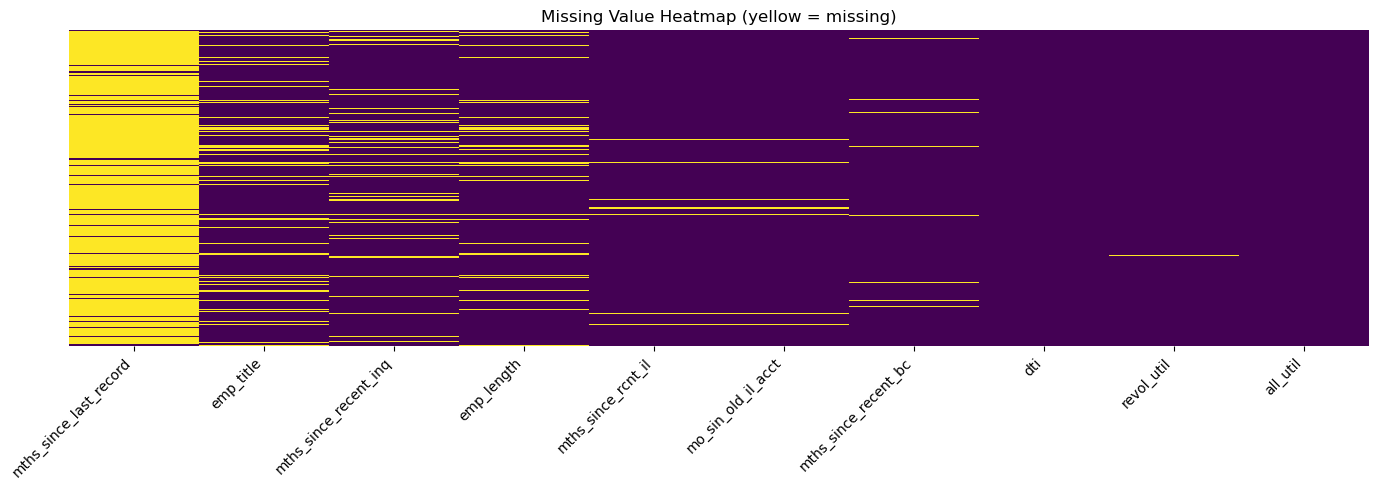

In [6]:
# ─────────────────────────────────────────────
# 1.3 Missing Value Analysis
# ─────────────────────────────────────────────

# Calculate missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns that have at least one missing value
missing = missing[missing['Missing Count'] > 0]

print("=== Columns with Missing Values ===")
print(missing.to_string())
print(f"\nTotal columns with missing values: {len(missing)}")

# Heatmap of missing values
plt.figure(figsize=(14, 5))
sns.heatmap(df[missing.index].isnull(),
            yticklabels=False,
            cbar=False,
            cmap='viridis')
plt.title('Missing Value Heatmap (yellow = missing)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observations: Missing Values

- **10 columns** contain missing values across the dataset.
- `mths_since_last_record` is missing in **90.88%** of rows — this is expected,
  as it only applies to borrowers with a public record (derogatory mark).
  Missingness here is **informative**, not random.
- `emp_title` (14.92%) and `emp_length` (8.67%) are categorical — filled with `'Unknown'`.
- The remaining 8 numeric columns have low-to-moderate missingness (<10%)
  and will be imputed with the **median** to remain robust against outliers.
- The target variable `int_rate` has **zero missing values** — no imputation needed.

In [7]:
# ─────────────────────────────────────────────
# 1.4 Missing Value Treatment
# ─────────────────────────────────────────────

# --- Categorical columns: fill with 'Unknown' ---
cat_fill = ['emp_title', 'emp_length']
for col in cat_fill:
    df[col].fillna('Unknown', inplace=True)

# --- Numeric columns: fill with median ---
num_fill = [
    'mths_since_last_record',
    'mths_since_recent_inq',
    'mths_since_rcnt_il',
    'mo_sin_old_il_acct',
    'mths_since_recent_bc',
    'dti',
    'revol_util',
    'all_util'
]
for col in num_fill:
    df[col].fillna(df[col].median(), inplace=True)

# --- Verify no missing values remain ---
remaining = df.isnull().sum().sum()
print(f"Total missing values after treatment: {remaining}")
print("\n=== Missing Value Check Per Column ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

if remaining == 0:
    print("\n✓ All missing values successfully treated.")

Total missing values after treatment: 0

=== Missing Value Check Per Column ===
Series([], dtype: int64)

✓ All missing values successfully treated.


/var/folders/yp/b_vv56tj2xs5th677vh9r1bc0000gn/T/ipykernel_91285/4035191402.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)
/var/folders/yp/b_vv56tj2xs5th677vh9r1bc0000gn/T/ipykernel_91285/4035191402.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

### 1.5 Numeric Feature Distributions
Visualizing the spread and shape of all numeric features to identify skewness,
outliers, and potential transformation needs before modeling.

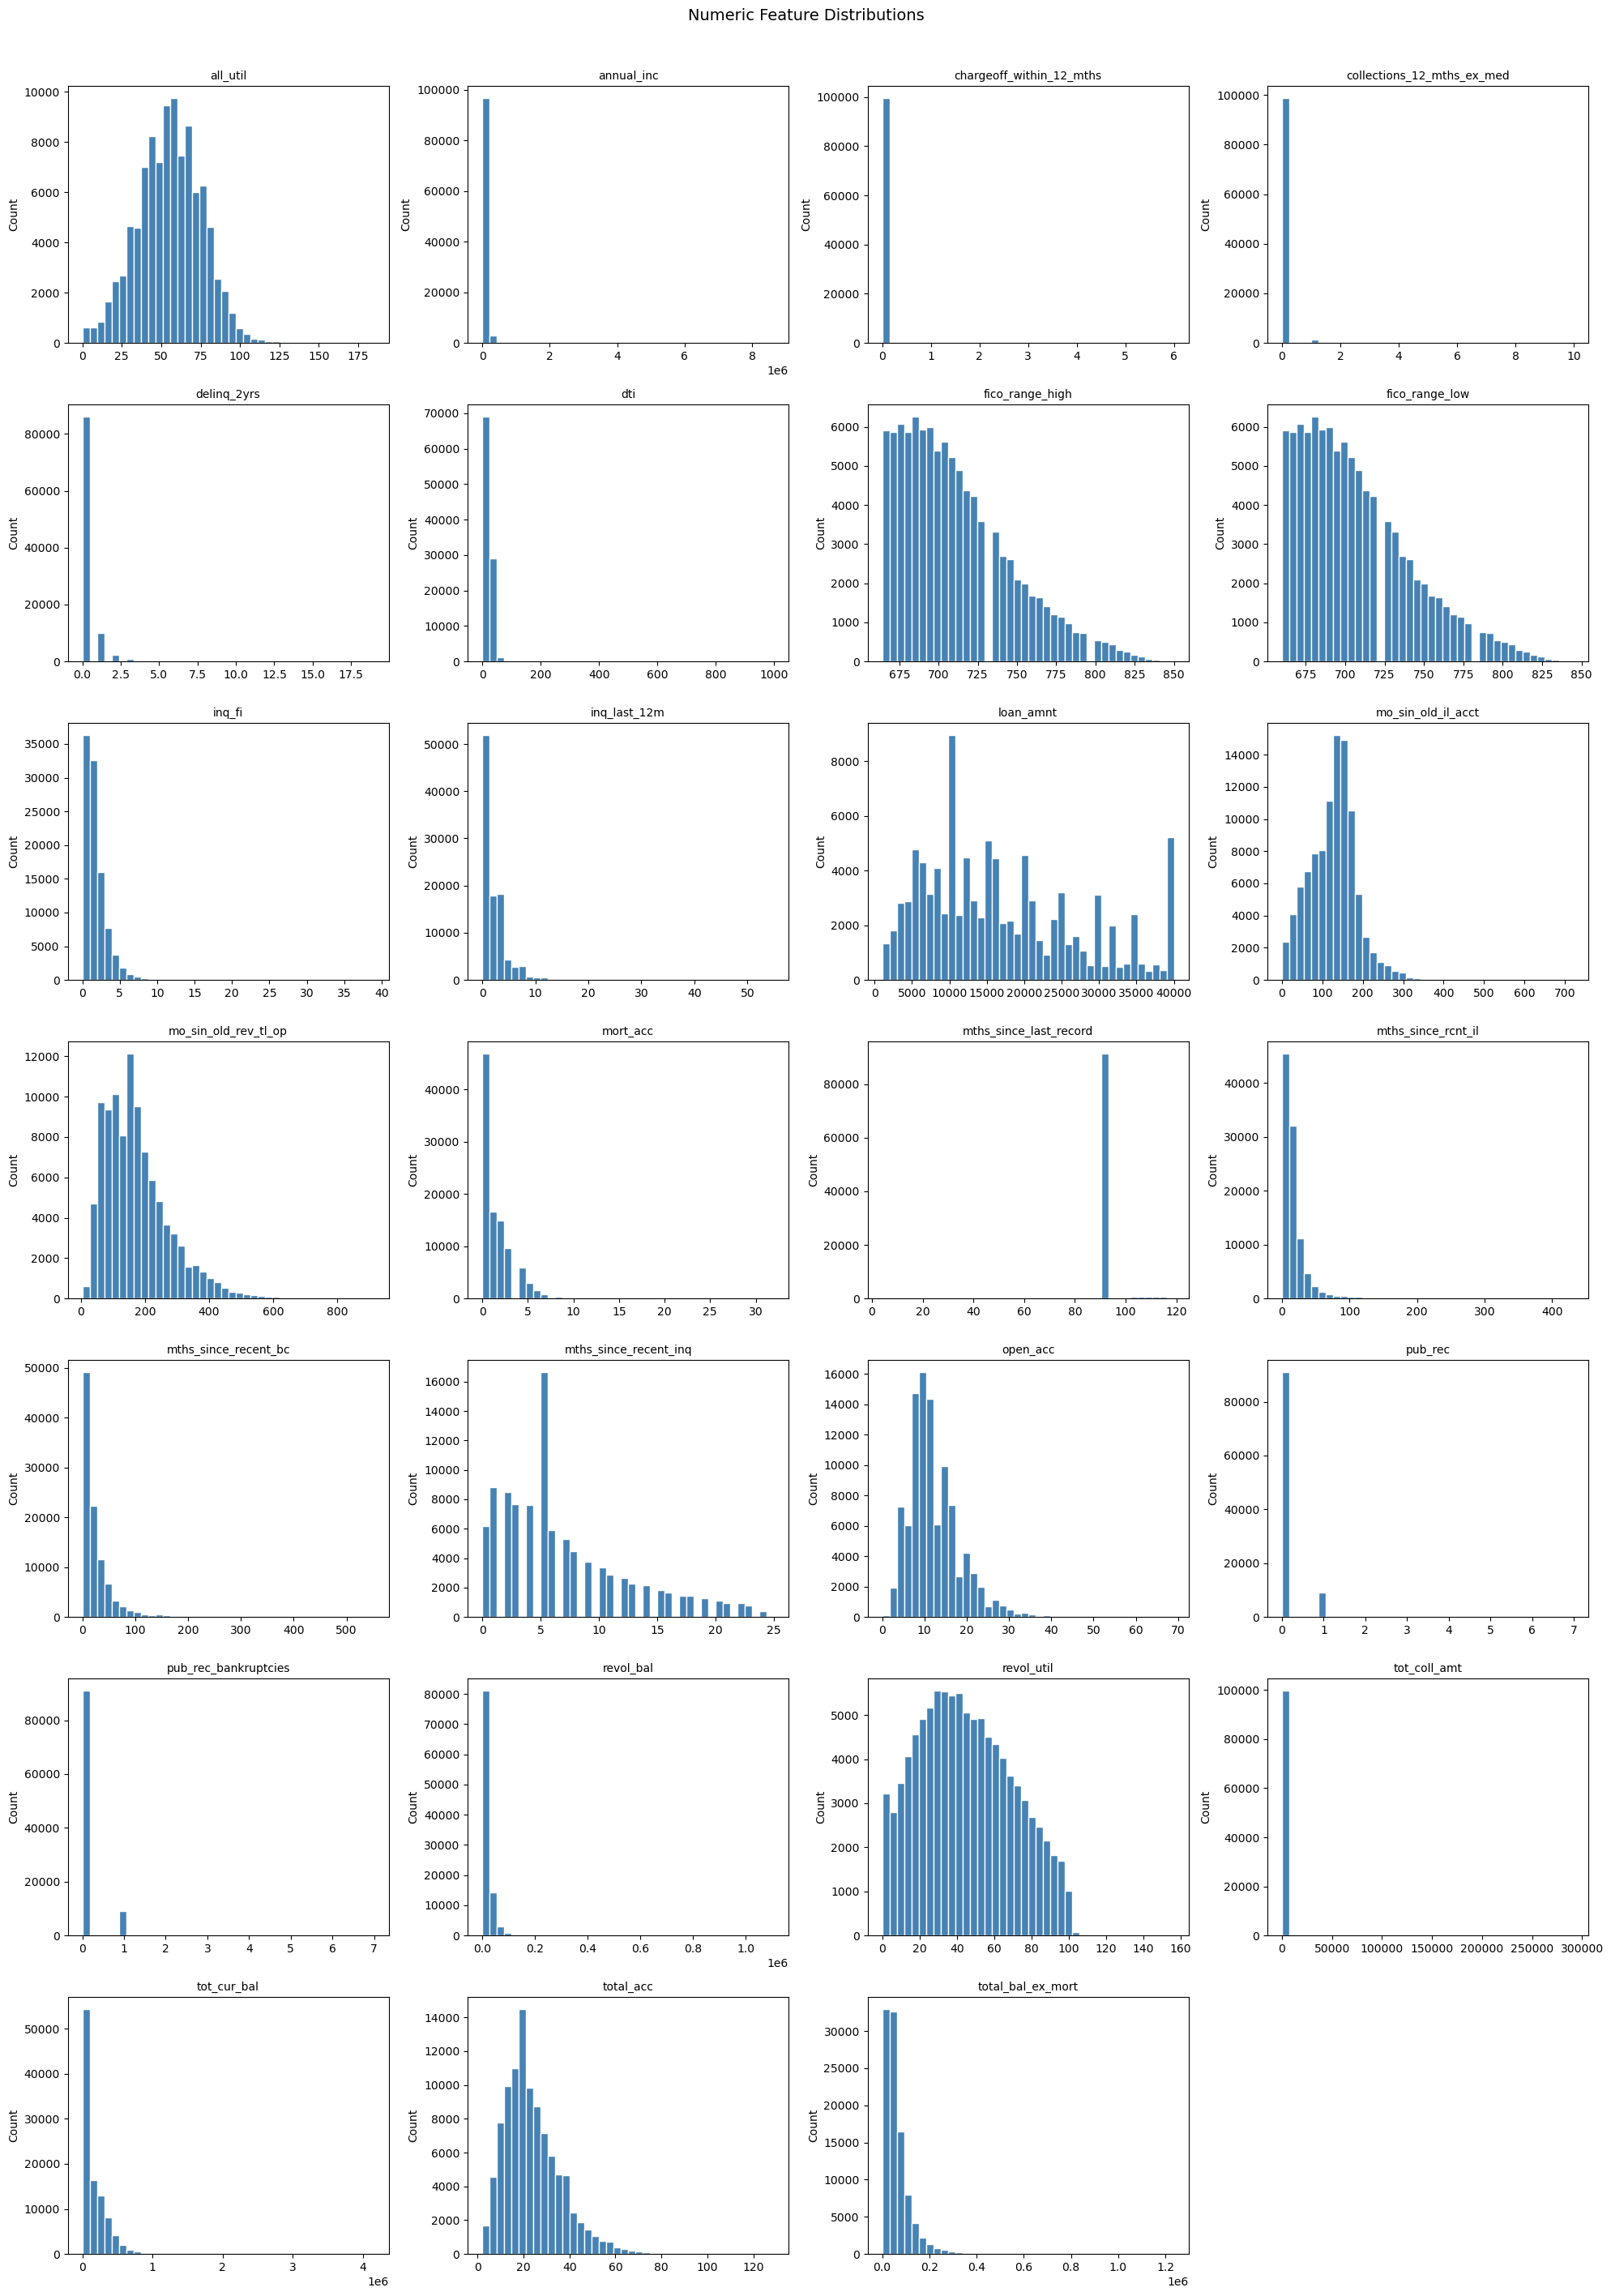

In [8]:
# ─────────────────────────────────────────────
# 1.5 Numeric Feature Distributions
# ─────────────────────────────────────────────

# All numeric columns except the target
numeric_features = [col for col in numeric_cols if col != target]

# Plot histograms for all numeric features
n_cols = 4
n_rows = -(-len(numeric_features) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Key Observations: Numeric Feature Distributions

- **Most features are right-skewed**, meaning a majority of borrowers cluster
  at lower values with a long tail of extreme cases. This is typical of financial data.
- **Notable heavily skewed features:** `annual_inc`, `revol_bal`, `tot_coll_amt`,
  `tot_cur_bal`, and `total_bal_ex_mort` — these may benefit from log transformation
  during feature engineering.
- **FICO scores** (`fico_range_high`, `fico_range_low`) show a roughly normal,
  left-bounded distribution centered around 700 — as expected for a lending platform.
- **`loan_amnt`** shows a discrete, multimodal pattern — borrowers tend to request
  round numbers (e.g., $ 5k, $ 10K, $15K).
- **`mths_since_last_record`** shows a large spike at the median-imputed value
  due to the 90.88% missingness treated earlier — this column should be used
  cautiously in modeling.
- **`pub_rec`, `pub_rec_bankruptcies`, `tot_coll_amt`** are near-zero for the
  vast majority of borrowers — low variance features that may have limited
  predictive power.

### 1.6 Categorical Feature Distributions
Examining the value counts and spread of all categorical features to identify
dominant categories, rare levels, and features that may need encoding.

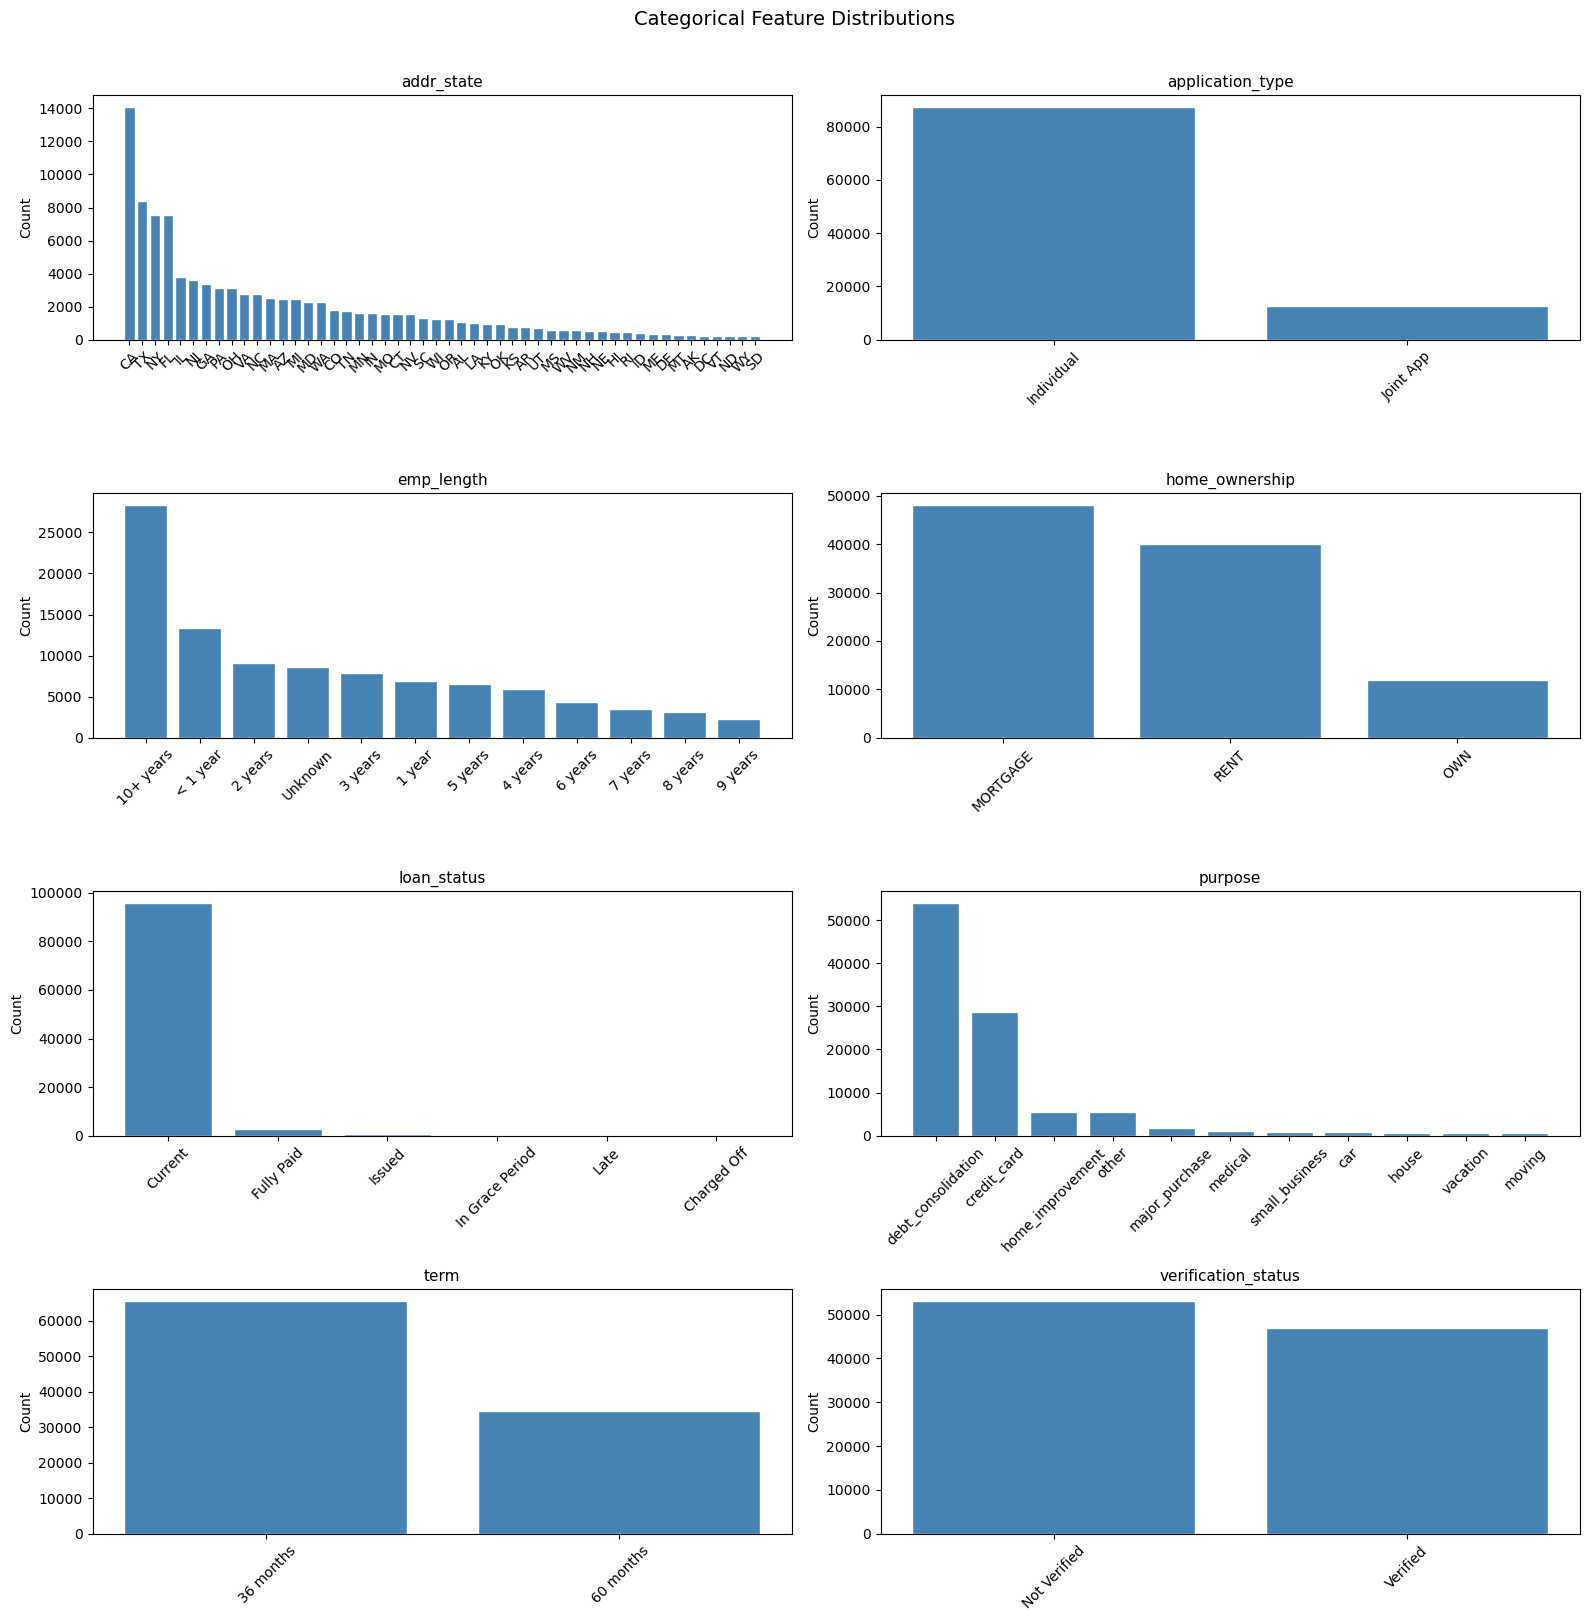

=== emp_title: Top 10 Values ===
emp_title
Unknown             14920
Teacher              1604
Manager              1408
Driver                788
Registered Nurse      737
RN                    558
Supervisor            512
Project Manager       488
Owner                 482
Sales                 482
Name: count, dtype: int64

=== title: Top 10 Values ===
title
Debt consolidation         53936
Credit card refinancing    28632
Home improvement            5609
Other                       5427
Major purchase              1759
Medical expenses            1159
Business                     878
Car financing                765
Home buying                  676
Vacation                     628
Name: count, dtype: int64

=== zip_code: Unique Values ===
Total unique zip codes: 873


In [9]:
# ─────────────────────────────────────────────
# 1.6 Categorical Feature Distributions
# ─────────────────────────────────────────────

# Categorical columns (excluding high-cardinality free text)
# emp_title and title have too many unique values to plot meaningfully
cat_plot_cols = [col for col in categorical_cols
                 if col not in ['emp_title', 'title', 'zip_code']]

n_cols = 2
n_rows = -(-len(cat_plot_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print value counts for high-cardinality columns separately
print("=== emp_title: Top 10 Values ===")
print(df['emp_title'].value_counts().head(10))

print("\n=== title: Top 10 Values ===")
print(df['title'].value_counts().head(10))

print("\n=== zip_code: Unique Values ===")
print(f"Total unique zip codes: {df['zip_code'].nunique()}")

In [ ]:
# ─────────────────────────────────────────────
# 1.7 Feature Correlation with Target (int_rate)
# ─────────────────────────────────────────────

# ── Part A: Numeric Correlations ─────────────

# Compute Pearson correlation of all numeric features with int_rate
numeric_corr = (
    df[numeric_cols]
    .corr()[target]
    .drop(target)                        # remove self-correlation
    .sort_values(key=abs, ascending=False)
)

print("=== Pearson Correlation with int_rate ===")
print(numeric_corr.round(4).to_string())

# Bar chart of correlations
plt.figure(figsize=(12, 7))
colors = ['steelblue' if v > 0 else 'tomato' for v in numeric_corr.values]
plt.barh(numeric_corr.index, numeric_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation of Numeric Features with int_rate\n(blue = positive, red = negative)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# ── Part B: Categorical Feature vs Target ─────

# For each categorical feature, plot mean int_rate per category level
cat_plot_cols_corr = [col for col in categorical_cols
                      if col not in ['emp_title', 'title', 'zip_code']]

n_cols = 2
n_rows = -(-len(cat_plot_cols_corr) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols_corr):
    means = (
        df.groupby(col)[target]
        .mean()
        .sort_values(ascending=False)
    )
    axes[i].bar(means.index, means.values,
                color='steelblue', edgecolor='white')
    axes[i].axhline(df[target].mean(), color='red',
                    linestyle='--', linewidth=1, label='Overall mean')
    axes[i].set_title(f'Mean int_rate by {col}', fontsize=11)
    axes[i].set_ylabel('Mean int_rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Mean Interest Rate by Categorical Feature Level',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Key Observations: Categorical Feature Distributions

- **`application_type`:** Heavily dominated by `Individual` (abt. 85%) vs `Joint App` —
  class imbalance to be aware of during encoding.
- **`term`:** Two values only — `36 months` (abt. 65%) and `60 months` (abt. 35%).
  Simple binary encode. Note: raw data contains a leading space (` 36 months`)
  that will need to be stripped during preprocessing.
- **`home_ownership`:** Three dominant categories — `MORTGAGE`, `RENT`, `OWN`.
  Clean and ready for encoding.
- **`purpose`:** `debt_consolidation` dominates (abt. 53K), followed by `credit_card`
  (abt. 29K). Remaining categories are sparse — may group rare levels later.
- **`loan_status`:** Nearly all loans are `Current` — this column reflects
  post-origination status and **must be dropped** before modeling to avoid
  data leakage (it would not be available at loan origination time).
- **`verification_status`:** Reasonably balanced across three levels — good
  candidate for encoding.
- **`emp_title`:** 873 unique zip codes and 14,920 `Unknown` values —
  too high cardinality for direct encoding, will be dropped.
- **`zip_code`:** 873 unique values — too high cardinality, will be dropped.
- **`title`:** Mirrors `purpose` closely — redundant, will be dropped.

### 1.7 Train/Test Split
Splitting the cleaned dataset into training and test sets before any modeling
begins. The test set is held out and will only be used for final model evaluation
— never for training or tuning decisions.

In [10]:
# ─────────────────────────────────────────────
# 1.7 Train/Test Split
# ─────────────────────────────────────────────

# Drop columns that cause data leakage or are not usable as features
# - loan_status: post-origination status, not available at loan origination
# - emp_title:   high cardinality free text, not useful for modeling
# - title:       redundant with purpose
# - zip_code:    high cardinality, not meaningful in raw form

cols_to_drop = ['loan_status', 'emp_title', 'title', 'zip_code']
df_model = df.drop(columns=cols_to_drop)

# Separate features and target
X = df_model.drop(columns=[target])
y = df_model[target]

# Split: 80% train, 20% test | random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Features used for modeling: {X.shape[1]}")
print(f"\nColumns dropped (leakage/unusable): {cols_to_drop}")
print(f"\nTraining set:   {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"Test set:       {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"\nTarget - Training: {y_train.shape[0]:,} values")
print(f"Target - Test:     {y_test.shape[0]:,} values")

# Confirm target distribution is preserved across splits
print(f"\n=== Target Distribution Check ===")
print(f"Train mean: {y_train.mean():.2f}% | Test mean: {y_test.mean():.2f}%")
print(f"Train std:  {y_train.std():.2f}%  | Test std:  {y_test.std():.2f}%")

Features used for modeling: 34

Columns dropped (leakage/unusable): ['loan_status', 'emp_title', 'title', 'zip_code']

Training set:   80,000 rows × 34 columns
Test set:       20,000 rows × 34 columns

Target - Training: 80,000 values
Target - Test:     20,000 values

=== Target Distribution Check ===
Train mean: 12.95% | Test mean: 12.94%
Train std:  5.26%  | Test std:  5.23%


### Key Observations: Train/Test Split

- Dataset split **80/20** → 80,000 training rows and 20,000 test rows.
- **4 columns dropped** prior to splitting:
  - `loan_status` — post-origination status, unavailable at loan origination (data leakage)
  - `emp_title` — high cardinality free text with limited predictive signal
  - `title` — redundant with `purpose`
  - `zip_code` — 873 unique values, not usable in raw form
- **34 features** remain for modeling after dropping target and leakage columns.
- Target distribution is well-preserved across both splits (mean and std
  nearly identical), confirming a representative and unbiased split.
- `random_state=42` ensures full reproducibility of results.
- The test set will not be touched again until final model evaluation.

# **Random Forest**

In [11]:
# -------------------------------------------------
# Baseline Random Forest
# -------------------------------------------------



RANDOM_STATE = 42

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    return {
        "model": name,
        "train_R2": r2_score(y_tr, pred_train),
        "test_R2": r2_score(y_te, pred_test),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr, pred_train)),
        "test_RMSE": np.sqrt(mean_squared_error(y_te, pred_test)),
        "train_MAE": mean_absolute_error(y_tr, pred_train),
        "test_MAE": mean_absolute_error(y_te, pred_test)
    }


rf_baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,        # faster than 200
        max_depth=15,           # prevents extremely deep trees
        min_samples_leaf=5,     # reduces overfitting and speeds training
        max_features="sqrt",    # fewer features checked at each split
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_baseline.fit(X_train, y_train)

baseline_results = evaluate_model(
    "Random Forest Baseline",
    rf_baseline,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([baseline_results])

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Random Forest Baseline,0.53,0.39,3.59,4.08,2.74,3.11


In [12]:
# -------------------------------------------------
# Random Forest Hyperparameter Tuning
# -------------------------------------------------

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_tuning_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": randint(30, 101),
    "model__max_depth": randint(8, 21),
    "model__min_samples_leaf": randint(3, 16),
    "model__max_features": ["sqrt", 0.4, 0.6]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipe,
    param_distributions=param_dist,
    n_iter=6,  # small enough to finish
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

rf_random_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_random_search.best_params_)
print(f"Best CV MAE: {-rf_random_search.best_score_:.4f} interest-rate points")

rf_best = rf_random_search.best_estimator_

rf_results = evaluate_model(
    "Random Forest Tuned",
    rf_best,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([baseline_results, rf_results])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END model__max_depth=14, model__max_features=sqrt, model__min_samples_leaf=13, model__n_estimators=90; total time=   9.7s
[CV] END model__max_depth=14, model__max_features=sqrt, model__min_samples_leaf=13, model__n_estimators=90; total time=  10.2s
[CV] END model__max_depth=14, model__max_features=sqrt, model__min_samples_leaf=13, model__n_estimators=90; total time=  10.4s
[CV] END model__max_depth=10, model__max_features=0.4, model__min_samples_leaf=7, model__n_estimators=31; total time=  11.0s
[CV] END model__max_depth=10, model__max_features=0.4, model__min_samples_leaf=7, model__n_estimators=31; total time=  11.5s
[CV] END model__max_depth=10, model__max_features=0.4, model__min_samples_leaf=7, model__n_estimators=31; total time=  10.9s
[CV] END model__max_depth=15, model__max_features=0.4, model__min_samples_leaf=8, model__n_estimators=31; total time=  13.0s
[CV] END model__max_depth=15, model__max_features=0.4, mode

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Random Forest Baseline,0.53,0.39,3.59,4.08,2.74,3.11
1,Random Forest Tuned,0.60,0.41,3.32,4.03,2.49,3.02


In [ ]:
#ANOUSHKA:
# ─────────────────────────────────────────────────────────────────
# RF Stage 1: Random Search
# Goal: sample 15 combinations across a wide hyperparameter space and identify which regions produce the lowest cross-validated MAE.
# ─────────────────────────────────────────────────────────────────

RANDOM_STATE = 42
cv3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Wide search space: deliberately broad to cover many possibilities
rf_random_param_dist = {
    "model__n_estimators":     randint(50, 301),                      # number of trees
    "model__max_depth":        randint(5, 16),                        # max tree depth
    "model__min_samples_leaf": randint(8, 25),                        # min samples at a leaf
    "model__max_features":     ["sqrt", "log2", 0.3, 0.5, 0.7],      # feature fraction per split
}

rf_random_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_random_search = RandomizedSearchCV(
    estimator=rf_random_pipe,
    param_distributions=rf_random_param_dist,
    n_iter=15,                # 15 random combinations
    cv=cv3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

rf_random_search.fit(X_train, y_train)

print("=== RF Random Search — Best Parameters ===")
print(rf_random_search.best_params_)
print(f"\nBest CV MAE: {-rf_random_search.best_score_:.4f} percentage points")

# Summarise all 15 trials:
rf_random_cv_results = (
    pd.DataFrame(rf_random_search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "param_model__max_features",
        "mean_test_score",
        "std_test_score"
    ]]
    .rename(columns={
        "mean_test_score": "cv_MAE (neg)",
        "std_test_score":  "cv_MAE_std"
    })
)
rf_random_cv_results["cv_MAE (neg)"] = -rf_random_cv_results["cv_MAE (neg)"]
display(rf_random_cv_results.head(10))

rf_best = rf_random_search.best_estimator_

rf_results = evaluate_model(
    "Random Forest (Random Search)",
    rf_best, X_train, y_train, X_test, y_test
)
pd.DataFrame([baseline_results, rf_results])

Fitting 3 folds for each of 15 candidates, totalling 45 fits
=== RF Random Search — Best Parameters ===
{'model__max_depth': 14, 'model__max_features': 0.7, 'model__min_samples_leaf': 19, 'model__n_estimators': 138}

Best CV MAE: 3.0636 percentage points


,rank_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features,cv_MAE (neg),cv_MAE_std
6,1,138,14,19,0.70,3.06,0.01
14,2,183,12,9,0.50,3.07,0.01
1,3,171,12,14,0.70,3.07,0.01
12,4,224,11,15,0.50,3.08,0.01
0,5,156,11,22,0.50,3.09,0.01
3,6,201,9,15,0.50,3.13,0.01
11,7,133,14,9,sqrt,3.16,0.02
8,8,278,7,10,0.50,3.20,0.01
9,9,216,7,16,0.70,3.20,0.01
4,10,137,7,9,0.70,3.20,0.01


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Random Forest Baseline,0.53,0.39,3.59,4.08,2.74,3.11
1,Random Forest (Random Search),0.53,0.41,3.60,4.02,2.70,3.02


In [14]:
#AM
# ─────────────────────────────────────────────────────────────────
# RF Stage 2: Grid Search
# Narrow grid centred on the best params found by Random Search.
# Exhaustive — tests every combination in the grid.
# ─────────────────────────────────────────────────────────────────

def neighbours(val, step, low, high, n=3):
    """Return n evenly spaced integers centred on val, clipped to [low, high]."""
    half = (n - 1) // 2
    return sorted(set(max(low, min(high, val + i * step)) for i in range(-half, half + 1)))

best_rf_rs = rf_random_search.best_params_

rf_grid_param = {
    "model__n_estimators":     neighbours(best_rf_rs["model__n_estimators"],     50,  50, 400),
    "model__max_depth":        neighbours(best_rf_rs["model__max_depth"],          2,   3,  30),
    "model__min_samples_leaf": neighbours(best_rf_rs["model__min_samples_leaf"],   2,   1,  30),
    "model__max_features":     [best_rf_rs["model__max_features"]],   # fix the best value
}

print("Grid Search space:")
for k, v in rf_grid_param.items():
    print(f"  {k}: {v}")
combos = 1
for v in rf_grid_param.values():
    combos *= len(v)
print(f"\nTotal combinations to evaluate: {combos} × 3 folds = {combos * 3} fits")

rf_grid_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_grid_search = GridSearchCV(
    estimator=rf_grid_pipe,
    param_grid=rf_grid_param,
    cv=cv3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

print("\n=== RF Grid Search — Best Parameters ===")
print(rf_grid_search.best_params_)
print(f"Best CV MAE: {-rf_grid_search.best_score_:.4f} percentage points")

rf_final = rf_grid_search.best_estimator_

rf_final_results = evaluate_model(
    "Random Forest (Grid Search)",
    rf_final, X_train, y_train, X_test, y_test
)
pd.DataFrame([baseline_results, rf_results, rf_final_results])

Grid Search space:
  model__n_estimators: [88, 138, 188]
  model__max_depth: [12, 14, 16]
  model__min_samples_leaf: [17, 19, 21]
  model__max_features: [0.7]

Total combinations to evaluate: 27 × 3 folds = 81 fits
Fitting 3 folds for each of 27 candidates, totalling 81 fits

=== RF Grid Search — Best Parameters ===
{'model__max_depth': 16, 'model__max_features': 0.7, 'model__min_samples_leaf': 17, 'model__n_estimators': 188}
Best CV MAE: 3.0568 percentage points


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Random Forest Baseline,0.53,0.39,3.59,4.08,2.74,3.11
1,Random Forest (Random Search),0.53,0.41,3.60,4.02,2.70,3.02
2,Random Forest (Grid Search),0.56,0.41,3.49,4.02,2.62,3.01


,feature,importance
6,num__fico_range_high,0.20
7,num__fico_range_low,0.18
5,num__dti,0.10
105,cat__term_ 36 months,0.06
0,num__all_util,0.05
10,num__loan_amnt,0.05
95,cat__purpose_credit_card,0.05
15,num__mths_since_rcnt_il,0.04
106,cat__term_ 60 months,0.03
21,num__revol_bal,0.03


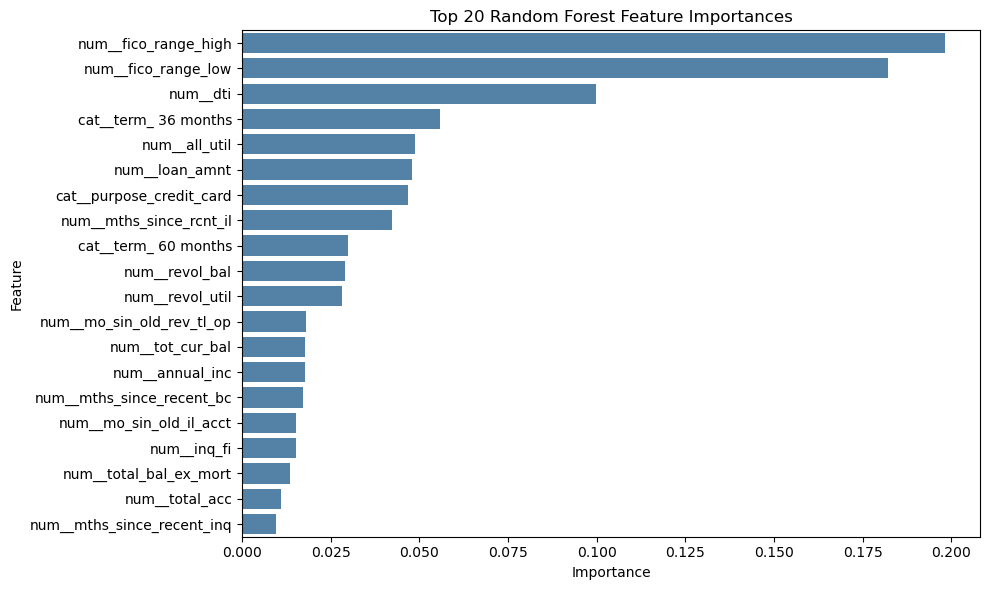

In [15]:
# -------------------------------------------------
# Random Forest Feature Importance
# -------------------------------------------------

feature_names = rf_best.named_steps["preprocess"].get_feature_names_out()
importances = rf_best.named_steps["model"].feature_importances_

rf_feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(rf_feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_feature_importance,
    x="importance",
    y="feature",
    color="steelblue"
)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,feature,importance_mean,importance_std
28,term,0.42,0.01
9,fico_range_high,0.36,0.01
10,fico_range_low,0.31,0.01
7,dti,0.19,0.02
25,purpose,0.16,0.02
14,loan_amnt,0.09,0.01
1,all_util,0.07,0.00
19,mths_since_rcnt_il,0.06,0.01
26,revol_bal,0.05,0.01
3,application_type,0.04,0.00


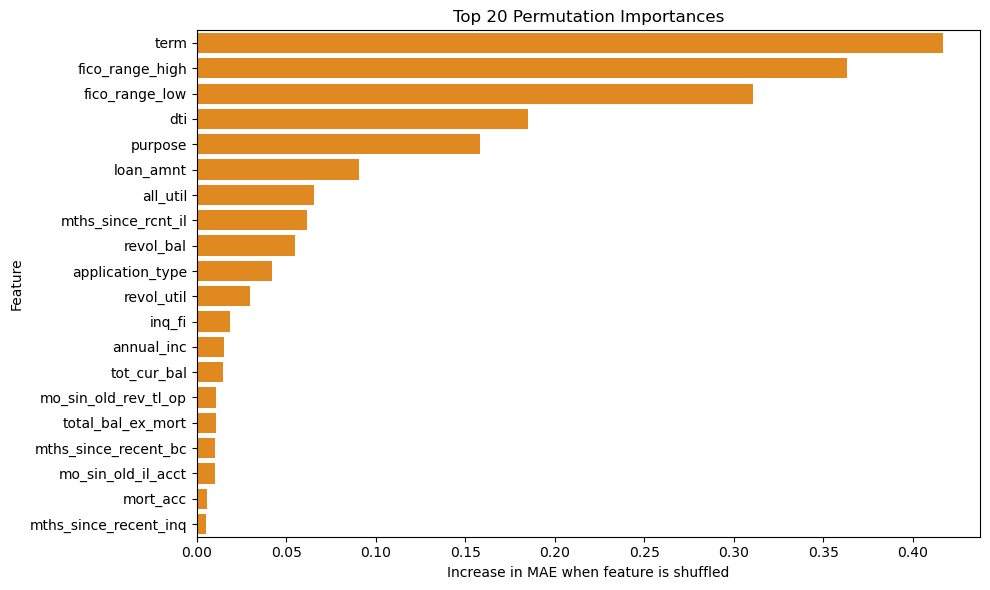

In [16]:
# -------------------------------------------------
# Permutation Importance
# -------------------------------------------------

# Use a sample for speed if the dataset is large
X_test_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=RANDOM_STATE
)
y_test_sample = y_test.loc[X_test_sample.index]

perm_importance = permutation_importance(
    rf_best,
    X_test_sample,
    y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

perm_importance_df = (
    pd.DataFrame({
        "feature": X_test_sample.columns,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .head(20)
)

display(perm_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=perm_importance_df,
    x="importance_mean",
    y="feature",
    color="darkorange"
)
plt.title("Top 20 Permutation Importances")
plt.xlabel("Increase in MAE when feature is shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

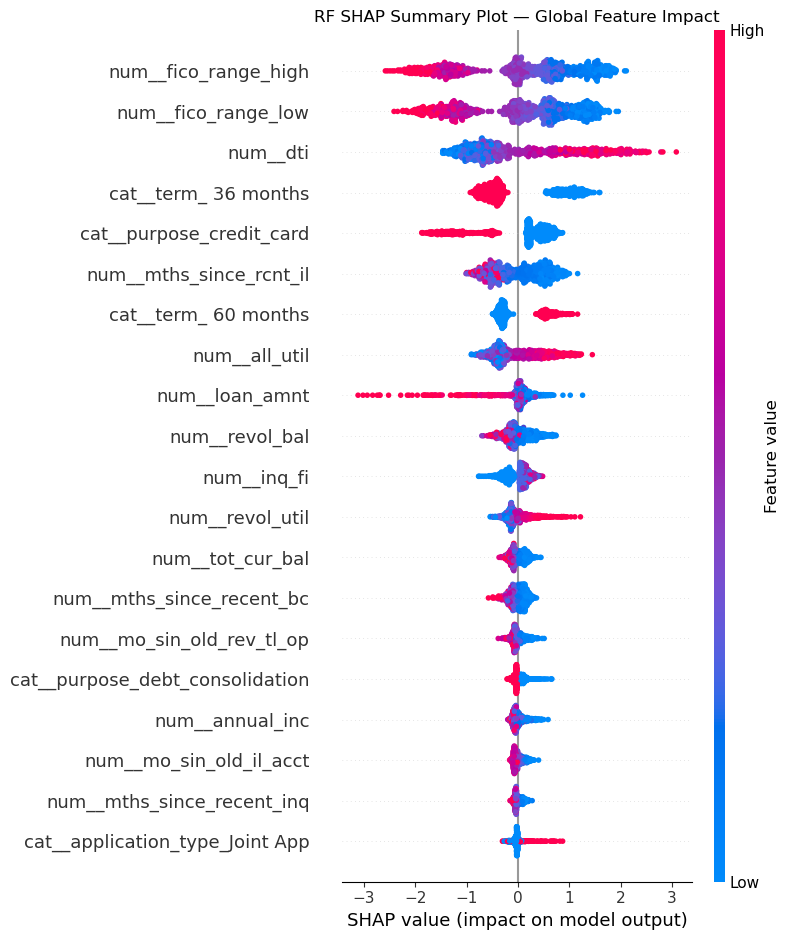

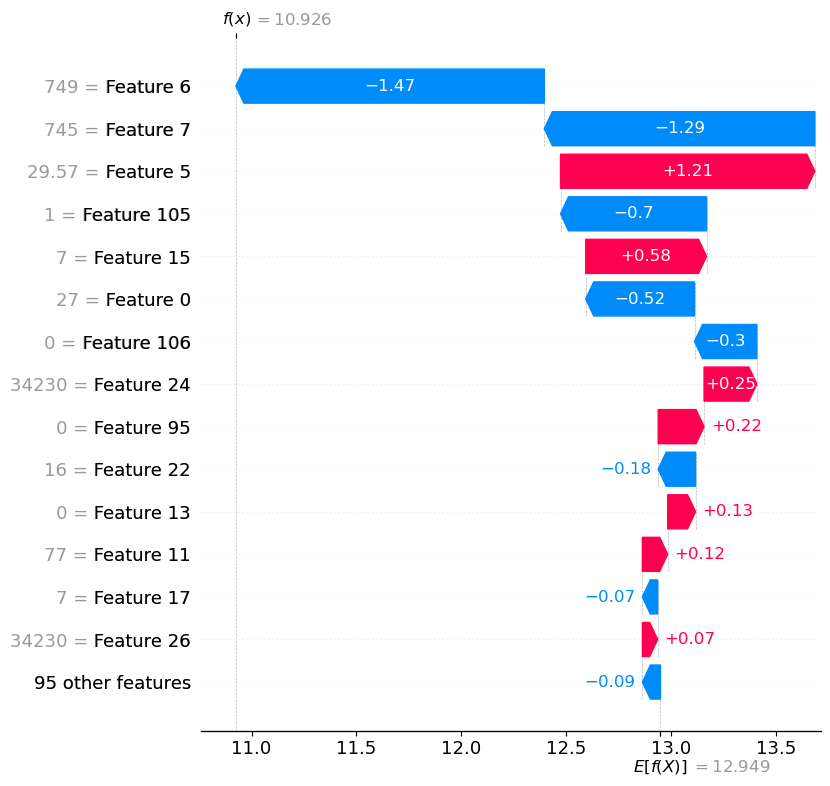

In [17]:
#AM
# ─────────────────────────────────────────────────────────────────
# RF SHAP: Local Explainability
# ─────────────────────────────────────────────────────────────────
import shap

# Transform data through preprocessing step
X_train_transformed = rf_best.named_steps["preprocess"].transform(X_train)
feature_names_out = rf_best.named_steps["preprocess"].get_feature_names_out()

# TreeExplainer is optimised for tree-based models
explainer = shap.TreeExplainer(rf_best.named_steps["model"])

# Sample for speed
X_shap_sample = X_train_transformed[:1000]
shap_values = explainer.shap_values(X_shap_sample)

# Global: Summary plot — feature importance + direction of effect
plt.figure()
shap.summary_plot(shap_values, X_shap_sample,
                  feature_names=feature_names_out, show=False)
plt.title("RF SHAP Summary Plot — Global Feature Impact")
plt.tight_layout()
plt.show()

# Local: Waterfall plot for a single prediction
shap_explanation = explainer(X_shap_sample)
shap.waterfall_plot(shap_explanation[0], max_display=15)

PDP features: ['loan_amnt', 'annual_inc', 'dti', 'fico_range_high']


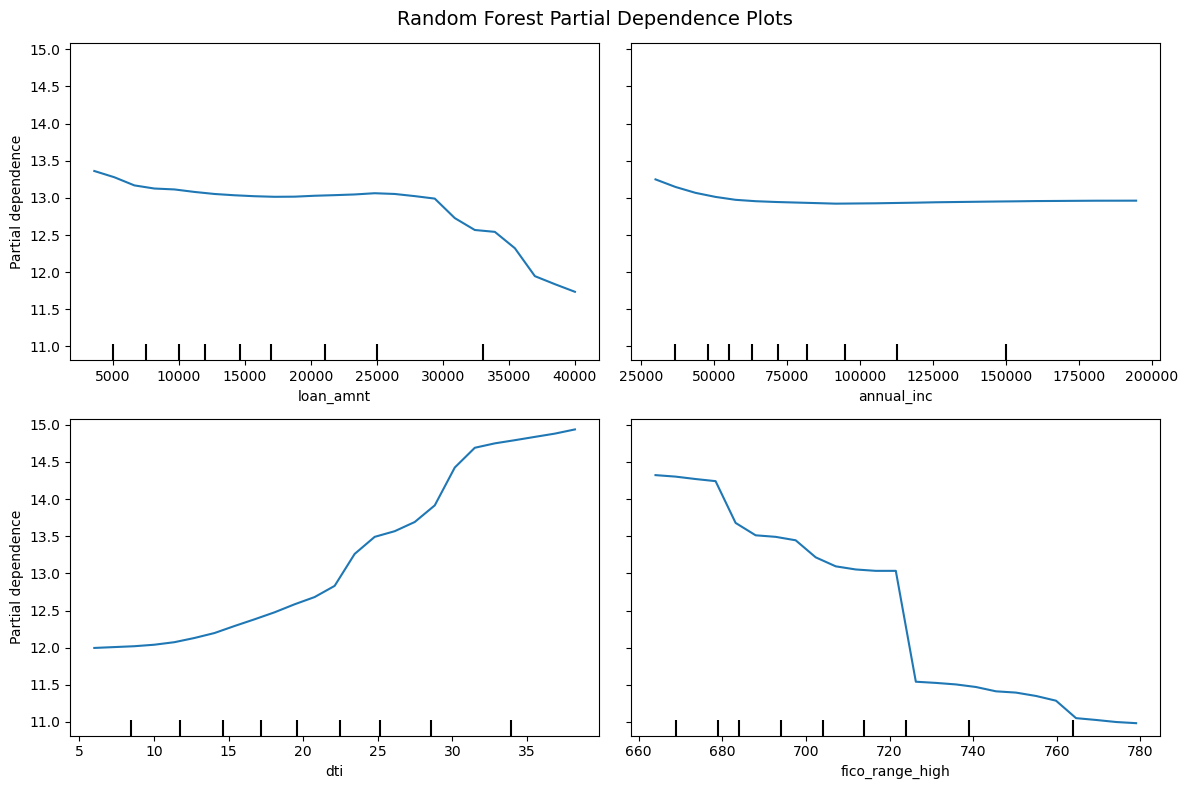

In [18]:
# -------------------------------------------------
# Partial Dependence Plots for Random Forest
# -------------------------------------------------

# Use a sample so PDPs run quickly on the large LendingClub dataset.
X_pdp = X_test.sample(n=min(3000, len(X_test)), random_state=RANDOM_STATE)

# Choose numeric features only because they produce the clearest PDP interpretation.
pdp_numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Prefer high-value business/model features if they are available.
preferred_pdp_features = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "fico_range_high",
    "revol_util",
    "fico_range_low",
    "term"
]

pdp_features = [
    feature for feature in preferred_pdp_features
    if feature in pdp_numeric_features
]

# If fewer than four preferred numeric features are present, fill in with other numeric columns.
if len(pdp_features) < 4:
    pdp_features += [
        feature for feature in pdp_numeric_features
        if feature not in pdp_features
    ]

pdp_features = pdp_features[:4]

print("PDP features:", pdp_features)

# Use the tuned Random Forest if it exists; otherwise use the baseline model.
rf_pdp_model = rf_best if "rf_best" in globals() else rf_baseline

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf_pdp_model,
    X_pdp,
    features=pdp_features,
    ax=ax,
    kind="average",
    grid_resolution=25
)
fig.suptitle("Random Forest Partial Dependence Plots", fontsize=14)
fig.tight_layout()
plt.show()

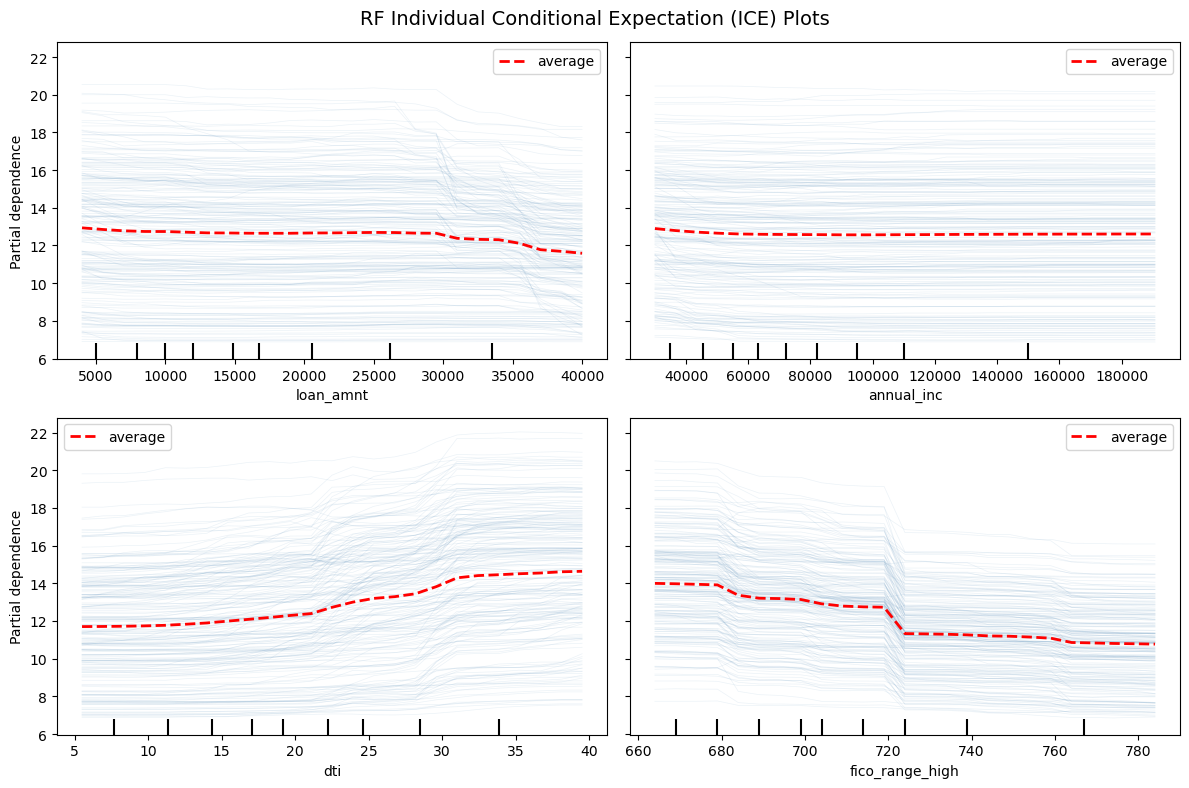

In [19]:
# AM
# ─────────────────────────────────────────────────────────────────
# RF ICE: Individual Conditional Expectation Plots
# kind="both" overlays individual ICE lines on the PDP average
# ─────────────────────────────────────────────────────────────────

X_ice = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf_best,
    X_ice,
    features=pdp_features,
    ax=ax,
    kind="both",           # "average" = PDP only; "both" = PDP + ICE lines
    subsample=200,         # number of ICE lines — avoids overcrowding
    grid_resolution=25,
    random_state=RANDOM_STATE,
    ice_lines_kw={"alpha": 0.1, "color": "steelblue"},
    pd_line_kw={"color": "red", "linewidth": 2}
)
fig.suptitle("RF Individual Conditional Expectation (ICE) Plots", fontsize=14)
fig.tight_layout()
plt.show()

# **Bayesian Regression and Gradient Boosting**


In [20]:
#FS
# =====================================================
# Bayesian Ridge Regression
# Goal: Add a regularized Bayesian linear model as a benchmark
# =====================================================

# Ensure required variables are defined for this cell
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cv3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def make_dense_onehot():
    return OneHotEncoder(handle_unknown="ignore", sparse_output=False)


bayes_numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

bayes_categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_dense_onehot())
])

bayes_preprocessor = ColumnTransformer([
    ("num", bayes_numeric_pipe, numeric_features),
    ("cat", bayes_categorical_pipe, categorical_features)
])

bayes_pipe = Pipeline([
    ("preprocess", bayes_preprocessor),
    ("model", BayesianRidge())
])

# Hyperparameter grid for Bayesian Ridge regularization terms
bayes_param_grid = {
    "model__alpha_1": [1e-6, 1e-5, 1e-4],
    "model__alpha_2": [1e-6, 1e-5, 1e-4],
    "model__lambda_1": [1e-6, 1e-5, 1e-4],
    "model__lambda_2": [1e-6, 1e-5, 1e-4]
}

bayes_grid_search = GridSearchCV(
    estimator=bayes_pipe,
    param_grid=bayes_param_grid,
    cv=cv3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

bayes_grid_search.fit(X_train, y_train)

print("=== FS Bayesian Ridge Regression - Best Parameters ===")
print(bayes_grid_search.best_params_)
print(f"\nBest CV MAE: {-bayes_grid_search.best_score_:.4f} interest-rate percentage points")

bayes_best = bayes_grid_search.best_estimator_

bayes_results = evaluate_model(
    "Bayesian Ridge Regression",
    bayes_best,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([bayes_results])

Fitting 3 folds for each of 81 candidates, totalling 243 fits
=== FS Bayesian Ridge Regression - Best Parameters ===
{'model__alpha_1': 1e-06, 'model__alpha_2': 0.0001, 'model__lambda_1': 0.0001, 'model__lambda_2': 1e-06}

Best CV MAE: 3.3377 interest-rate percentage points


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Bayesian Ridge Regression,0.33,0.34,4.29,4.26,3.33,3.30


In [21]:
#FS
# =====================================================
# Gradient Boosting Regression
# Goal: Add a nonlinear boosting model for comparison
# Faster version using a tuning sample
# =====================================================

X_gb_tune, _, y_gb_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=min(20000, len(X_train)),
    random_state=RANDOM_STATE
)

gb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

# Smaller search space for faster runtime
gb_param_dist = {
    "model__n_estimators": randint(50, 121),
    "model__learning_rate": uniform(0.05, 0.10),
    "model__max_depth": randint(2, 4),
    "model__min_samples_leaf": randint(10, 31),
    "model__subsample": uniform(0.7, 0.3)
}

gb_random_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_param_dist,
    n_iter=4,
    cv=cv3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

gb_random_search.fit(X_gb_tune, y_gb_tune)

print("=== FS Gradient Boosting Regression - Best Parameters ===")
print(gb_random_search.best_params_)
print(f"\nBest CV MAE: {-gb_random_search.best_score_:.4f} interest-rate percentage points")

# Fit the selected Gradient Boosting model on the full training data
gb_best = gb_random_search.best_estimator_
gb_best.fit(X_train, y_train)

gb_results = evaluate_model(
    "Gradient Boosting Regression",
    gb_best,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([gb_results])

Fitting 3 folds for each of 4 candidates, totalling 12 fits
=== FS Gradient Boosting Regression - Best Parameters ===
{'model__learning_rate': np.float64(0.08745401188473625), 'model__max_depth': 2, 'model__min_samples_leaf': 24, 'model__n_estimators': 110, 'model__subsample': np.float64(0.879055047383946)}

Best CV MAE: 3.1606 interest-rate percentage points


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Gradient Boosting Regression,0.39,0.39,4.12,4.10,3.14,3.12


# **XG Boost**

In [22]:
# -------------------------------------------------
# XGBoost Model: LendingClub Interest Rate Prediction
# -------------------------------------------------

RANDOM_STATE = 42

# Reuse the train/test split created in Section 1.7.
# This keeps XGBoost comparable with the Random Forest model.
xgb_numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
xgb_categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numeric features: {len(xgb_numeric_features)}")
print(f"Categorical features: {len(xgb_categorical_features)}")

xgb_numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

xgb_categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

xgb_preprocessor = ColumnTransformer([
    ("num", xgb_numeric_pipe, xgb_numeric_features),
    ("cat", xgb_categorical_pipe, xgb_categorical_features)
])


def evaluate_xgb_model(name, model, X_tr, y_tr, X_te, y_te):
    """Evaluate predictions in interest-rate percentage points."""
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    return {
        "model": name,
        "train_R2": r2_score(y_tr, pred_train),
        "test_R2": r2_score(y_te, pred_test),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr, pred_train)),
        "test_RMSE": np.sqrt(mean_squared_error(y_te, pred_test)),
        "train_MAE": mean_absolute_error(y_tr, pred_train),
        "test_MAE": mean_absolute_error(y_te, pred_test)
    }

Numeric features: 27
Categorical features: 7


In [23]:
# -------------------------------------------------
# Baseline XGBoost Regressor
# -------------------------------------------------

xgb_baseline = Pipeline([
    ("preprocess", xgb_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_baseline.fit(X_train, y_train)

xgb_baseline_results = evaluate_xgb_model(
    "XGBoost Baseline",
    xgb_baseline,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([xgb_baseline_results])

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,XGBoost Baseline,0.46,0.44,3.87,3.93,2.91,2.95


In [24]:
# -------------------------------------------------
# XGBoost Hyperparameter Tuning
# -------------------------------------------------

xgb_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_param_dist = {
    "model__n_estimators": randint(200, 701),
    "model__max_depth": randint(3, 8),
    "model__learning_rate": uniform(0.02, 0.12),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),
    "model__min_child_weight": randint(1, 10),
    "model__reg_lambda": uniform(0.5, 2.0)
}

xgb_tuning_pipe = Pipeline([
    ("preprocess", xgb_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipe,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=xgb_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)
print(f"Best CV MAE: {-xgb_random_search.best_score_:.4f} interest-rate points")

xgb_best = xgb_random_search.best_estimator_

xgb_results = evaluate_xgb_model(
    "XGBoost Tuned",
    xgb_best,
    X_train,
    y_train,
    X_test,
    y_test
)

pd.DataFrame([xgb_baseline_results, xgb_results])

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost parameters:
{'model__colsample_bytree': np.float64(0.8275467623473733), 'model__learning_rate': np.float64(0.04495299954418266), 'model__max_depth': 6, 'model__min_child_weight': 6, 'model__n_estimators': 676, 'model__reg_lambda': np.float64(2.439169255529117), 'model__subsample': np.float64(0.9325398470083344)}
Best CV MAE: 2.9257 interest-rate points


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,XGBoost Baseline,0.46,0.44,3.87,3.93,2.91,2.95
1,XGBoost Tuned,0.57,0.45,3.43,3.87,2.57,2.89


In [25]:
# AM
#─────────────────────────────────────────────────────────────────
# XGBoost Stage 1: Random Search
# Wide space — 20 random combinations, 3-fold CV.
# ─────────────────────────────────────────────────────────────────

xgb_random_param_dist = {
    "model__n_estimators":     randint(100, 600),     # boosting rounds
    "model__max_depth":        randint(3, 9),          # tree depth
    "model__learning_rate":    uniform(0.01, 0.19),    # shrinkage (0.01–0.20)
    "model__subsample":        uniform(0.60, 0.40),    # row sampling (0.60–1.00)
    "model__colsample_bytree": uniform(0.60, 0.40),    # column sampling (0.60–1.00)
    "model__min_child_weight": randint(1, 11),         # min sum of instance weight
    "model__reg_lambda":       uniform(0.5, 4.5),      # L2 regularisation
}

xgb_random_pipe = Pipeline([
    ("preprocess", xgb_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_random_pipe,
    param_distributions=xgb_random_param_dist,
    n_iter=20,
    cv=cv3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)

xgb_random_search.fit(X_train, y_train)

print("=== XGBoost Random Search — Best Parameters ===")
print(xgb_random_search.best_params_)
print(f"\nBest CV MAE: {-xgb_random_search.best_score_:.4f} percentage points")

# Show top-10 trials
xgb_random_cv_results = (
    pd.DataFrame(xgb_random_search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__learning_rate",
        "param_model__subsample",
        "mean_test_score",
        "std_test_score"
    ]]
    .rename(columns={"mean_test_score": "cv_MAE (neg)", "std_test_score": "cv_MAE_std"})
)
xgb_random_cv_results["cv_MAE (neg)"] = -xgb_random_cv_results["cv_MAE (neg)"]
display(xgb_random_cv_results.head(10))

xgb_best = xgb_random_search.best_estimator_

xgb_results = evaluate_xgb_model(
    "XGBoost (Random Search)",
    xgb_best, X_train, y_train, X_test, y_test
)
pd.DataFrame([xgb_baseline_results, xgb_results])

Fitting 3 folds for each of 20 candidates, totalling 60 fits
=== XGBoost Random Search — Best Parameters ===
{'model__colsample_bytree': np.float64(0.8170784332632994), 'model__learning_rate': np.float64(0.0367756027452049), 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 444, 'model__reg_lambda': np.float64(4.940991214702327), 'model__subsample': np.float64(0.908897907718663)}

Best CV MAE: 2.9225 percentage points


,rank_test_score,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__subsample,cv_MAE (neg),cv_MAE_std
11,1,444,7,0.04,0.91,2.92,0.01
8,2,576,6,0.05,0.91,2.92,0.01
17,3,506,6,0.07,0.82,2.93,0.01
14,4,392,8,0.02,0.86,2.93,0.01
7,5,519,5,0.10,0.90,2.94,0.01
6,6,485,4,0.08,0.78,2.94,0.01
19,7,385,6,0.03,0.73,2.94,0.01
10,8,379,4,0.08,0.71,2.95,0.01
4,9,463,8,0.08,0.84,2.95,0.01
18,10,185,5,0.19,0.85,2.95,0.01


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,XGBoost Baseline,0.46,0.44,3.87,3.93,2.91,2.95
1,XGBoost (Random Search),0.58,0.45,3.43,3.87,2.56,2.89


In [26]:
# AM
# ─────────────────────────────────────────────────────────────────
# XGBoost Stage 2: Grid Search
# Fix the best continuous params; sweep discrete neighbours.
# ─────────────────────────────────────────────────────────────────

best_xgb_rs = xgb_random_search.best_params_

# Round continuous params to sensible grid values
lr_best = round(best_xgb_rs["model__learning_rate"], 2)
ss_best = round(best_xgb_rs["model__subsample"], 1)
cs_best = round(best_xgb_rs["model__colsample_bytree"], 1)

xgb_grid_param = {
    "model__n_estimators":     neighbours(best_xgb_rs["model__n_estimators"], 100, 100, 800),
    "model__max_depth":        neighbours(best_xgb_rs["model__max_depth"],       1,   2,  10),
    "model__learning_rate":    sorted(set([max(0.01, lr_best - 0.02), lr_best, min(0.20, lr_best + 0.02)])),
    "model__subsample":        sorted(set([max(0.5,  ss_best - 0.1),  ss_best, min(1.0,  ss_best + 0.1)])),
    "model__colsample_bytree": [cs_best],                                    # fix best value
    "model__min_child_weight": [best_xgb_rs["model__min_child_weight"]],     # fix best
    "model__reg_lambda":       [round(best_xgb_rs["model__reg_lambda"], 1)], # fix best
}

print("Grid Search space:")
for k, v in xgb_grid_param.items():
    print(f"  {k}: {v}")
combos = 1
for v in xgb_grid_param.values():
    combos *= len(v)
print(f"\nTotal combinations: {combos} × 3 folds = {combos * 3} fits")

xgb_grid_pipe = Pipeline([
    ("preprocess", xgb_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_grid_search = GridSearchCV(
    estimator=xgb_grid_pipe,
    param_grid=xgb_grid_param,
    cv=cv3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_grid_search.fit(X_train, y_train)

print("\n=== XGBoost Grid Search — Best Parameters ===")
print(xgb_grid_search.best_params_)
print(f"Best CV MAE: {-xgb_grid_search.best_score_:.4f} percentage points")

xgb_final = xgb_grid_search.best_estimator_

xgb_final_results = evaluate_xgb_model(
    "XGBoost (Grid Search)",
    xgb_final, X_train, y_train, X_test, y_test
)
pd.DataFrame([xgb_baseline_results, xgb_results, xgb_final_results])

Grid Search space:
  model__n_estimators: [344, 444, 544]
  model__max_depth: [6, 7, 8]
  model__learning_rate: [np.float64(0.02), np.float64(0.04), np.float64(0.06)]
  model__subsample: [np.float64(0.8), np.float64(0.9), 1.0]
  model__colsample_bytree: [np.float64(0.8)]
  model__min_child_weight: [1]
  model__reg_lambda: [np.float64(4.9)]

Total combinations: 81 × 3 folds = 243 fits
Fitting 3 folds for each of 81 candidates, totalling 243 fits


KeyboardInterrupt: 

,feature,importance
7,num__fico_range_low,0.10
106,cat__term_ 60 months,0.09
6,num__fico_range_high,0.08
95,cat__purpose_credit_card,0.07
105,cat__term_ 36 months,0.07
32,cat__addr_state_CO,0.04
77,cat__application_type_Individual,0.02
5,num__dti,0.02
96,cat__purpose_debt_consolidation,0.02
78,cat__application_type_Joint App,0.02


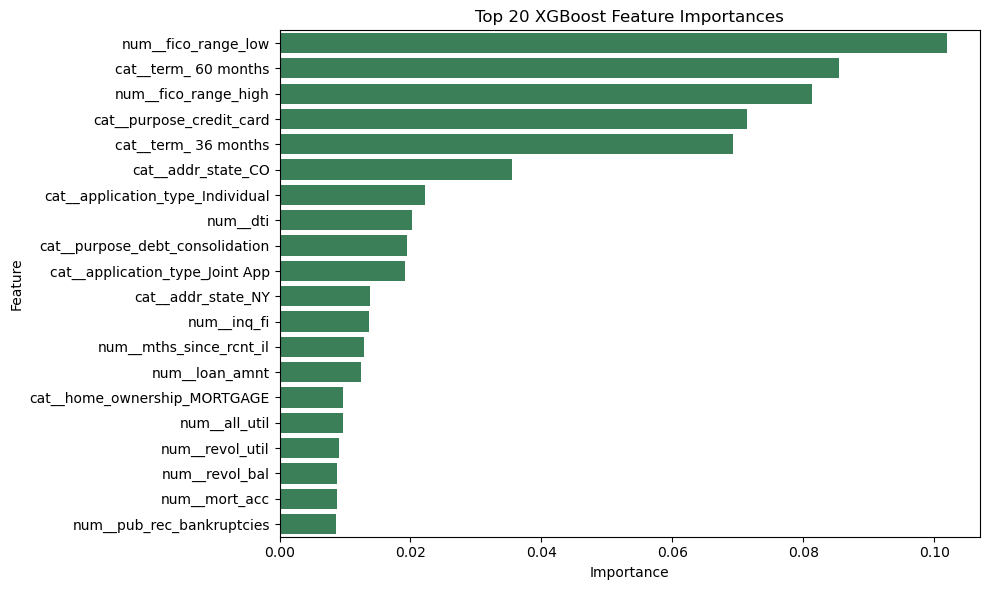

In [ ]:
# -------------------------------------------------
# XGBoost Feature Importance
# -------------------------------------------------

xgb_feature_names = xgb_best.named_steps["preprocess"].get_feature_names_out()
xgb_importances = xgb_best.named_steps["model"].feature_importances_

xgb_feature_importance = (
    pd.DataFrame({
        "feature": xgb_feature_names,
        "importance": xgb_importances
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(xgb_feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_feature_importance,
    x="importance",
    y="feature",
    color="seagreen"
)
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

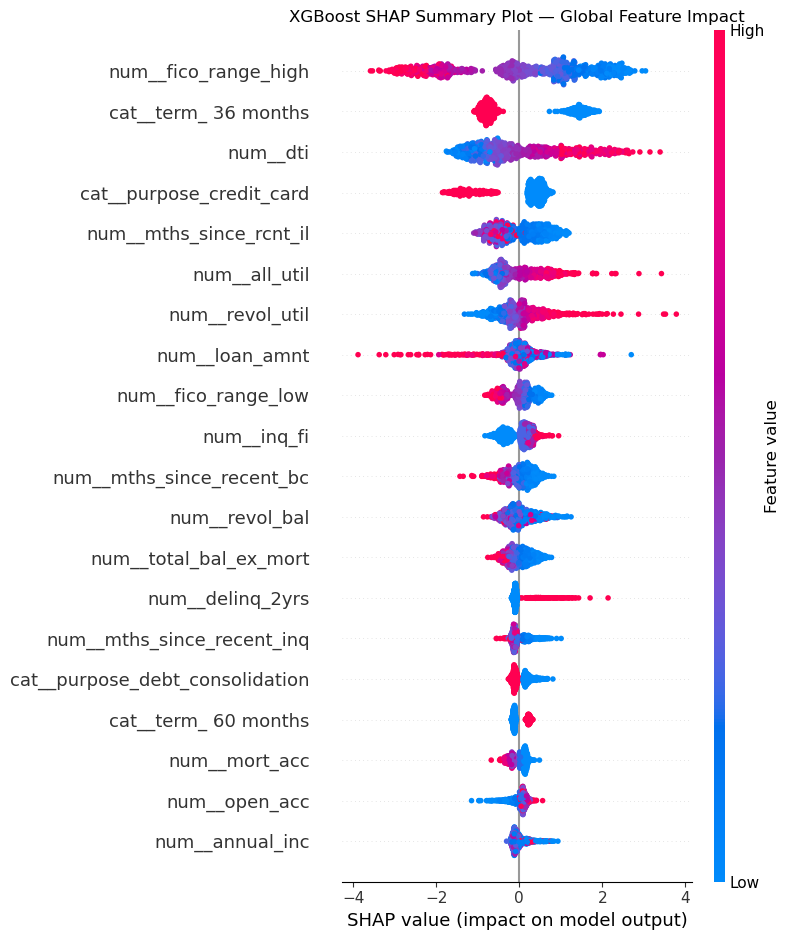

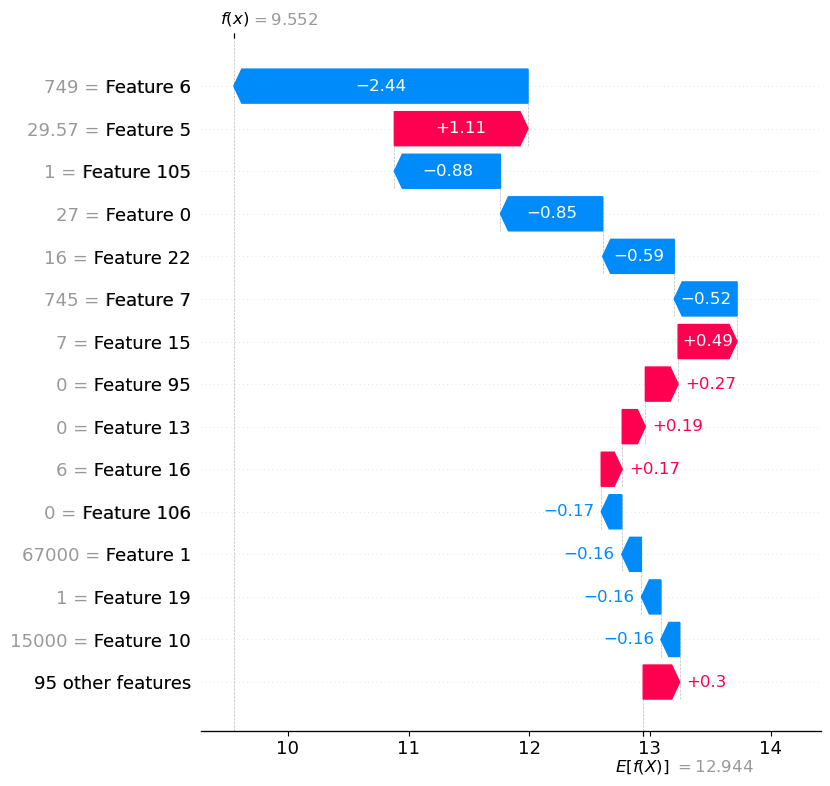

In [ ]:
# AM
# ─────────────────────────────────────────────────────────────────
# XGBoost SHAP: Local Explainability
# ─────────────────────────────────────────────────────────────────

X_train_xgb_transformed = xgb_best.named_steps["preprocess"].transform(X_train)
xgb_feature_names_out = xgb_best.named_steps["preprocess"].get_feature_names_out()

xgb_explainer = shap.TreeExplainer(xgb_best.named_steps["model"])

X_xgb_shap_sample = X_train_xgb_transformed[:1000]
xgb_shap_values = xgb_explainer.shap_values(X_xgb_shap_sample)

# Global: Summary plot
plt.figure()
shap.summary_plot(xgb_shap_values, X_xgb_shap_sample,
                  feature_names=xgb_feature_names_out, show=False)
plt.title("XGBoost SHAP Summary Plot — Global Feature Impact")
plt.tight_layout()
plt.show()

# Local: Waterfall plot for a single prediction
xgb_shap_explanation = xgb_explainer(X_xgb_shap_sample)
shap.waterfall_plot(xgb_shap_explanation[0], max_display=15)

,feature,importance_mean,importance_std
9,fico_range_high,0.64,0.01
28,term,0.44,0.01
7,dti,0.23,0.02
14,loan_amnt,0.18,0.01
25,purpose,0.17,0.01
27,revol_util,0.12,0.00
26,revol_bal,0.11,0.01
1,all_util,0.09,0.00
19,mths_since_rcnt_il,0.07,0.00
10,fico_range_low,0.05,0.00


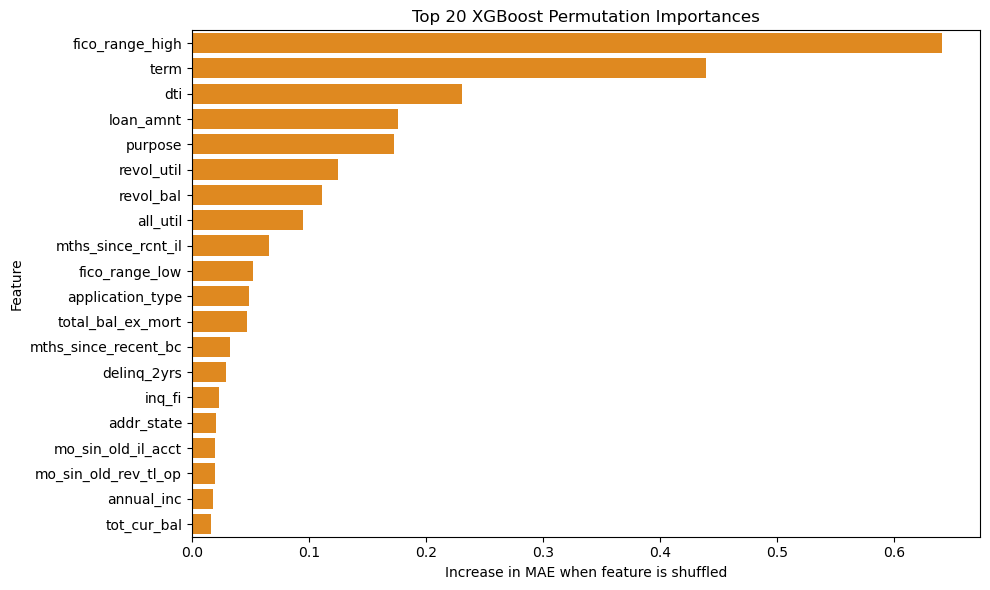

In [ ]:
# -------------------------------------------------
# Permutation Importance
# -------------------------------------------------

# Use a sample to keep runtime manageable on the large LendingClub dataset.
X_test_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=RANDOM_STATE
)
y_test_sample = y_test.loc[X_test_sample.index]

xgb_perm_importance = permutation_importance(
    xgb_best,
    X_test_sample,
    y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

xgb_perm_importance_df = (
    pd.DataFrame({
        "feature": X_test_sample.columns,
        "importance_mean": xgb_perm_importance.importances_mean,
        "importance_std": xgb_perm_importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .head(20)
)

display(xgb_perm_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_perm_importance_df,
    x="importance_mean",
    y="feature",
    color="darkorange"
)
plt.title("Top 20 XGBoost Permutation Importances")
plt.xlabel("Increase in MAE when feature is shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

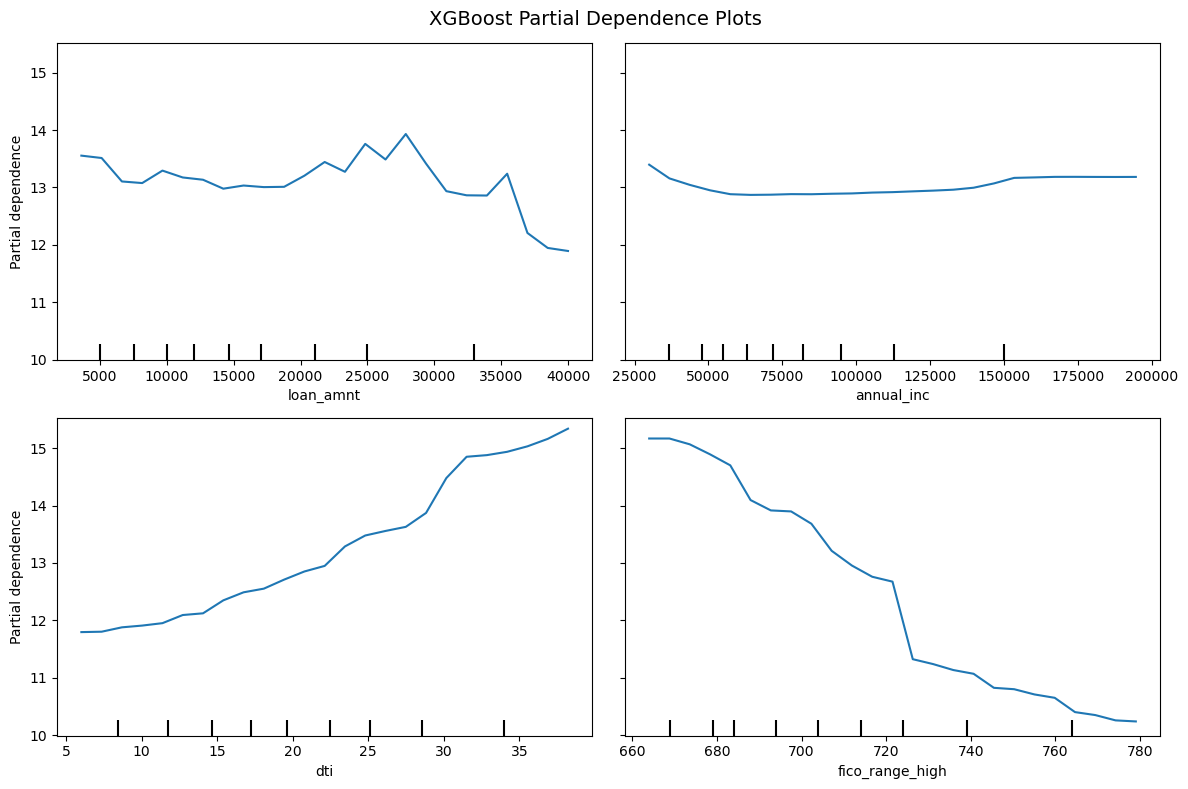

In [ ]:
# -------------------------------------------------
# Partial Dependence Plots for XGBoost
# -------------------------------------------------

# XGBoost PDPs require xgb_best to be trained first.
if "xgb_best" in globals():
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    PartialDependenceDisplay.from_estimator(
        xgb_best,
        X_pdp,
        features=pdp_features,
        ax=ax,
        kind="average",
        grid_resolution=25
    )
    fig.suptitle("XGBoost Partial Dependence Plots", fontsize=14)
    fig.tight_layout()
    plt.show()

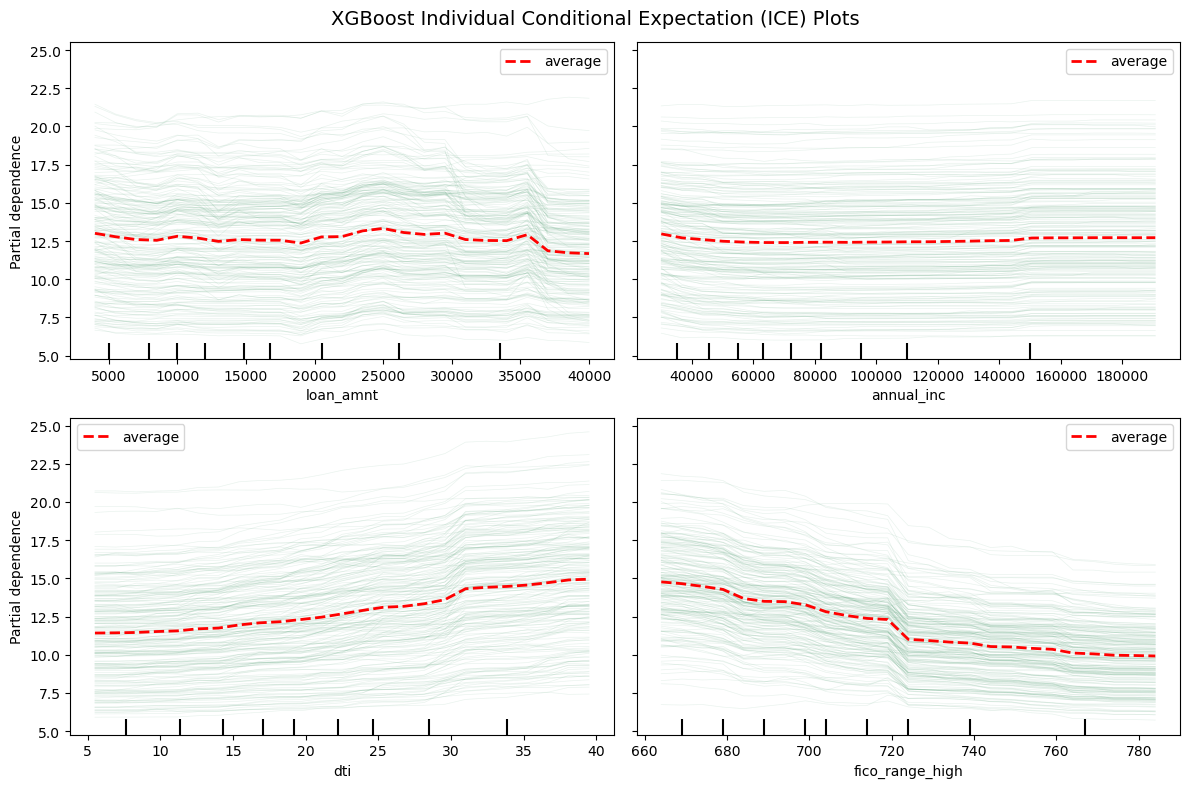

In [ ]:
#AM
#  ─────────────────────────────────────────────────────────────────
# XGBoost ICE: Individual Conditional Expectation Plots
# ─────────────────────────────────────────────────────────────────

X_ice_xgb = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    xgb_best,
    X_ice_xgb,
    features=pdp_features,
    ax=ax,
    kind="both",
    subsample=200,
    grid_resolution=25,
    random_state=RANDOM_STATE,
    ice_lines_kw={"alpha": 0.1, "color": "seagreen"},
    pd_line_kw={"color": "red", "linewidth": 2}
)
fig.suptitle("XGBoost Individual Conditional Expectation (ICE) Plots", fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------
# Using XGBoost to predict Interest Rates for LC_test.csv
# -------------------------------------------------

lc_test = pd.read_csv("LC_test.csv")

# Preserve ID for submission if LC_test includes it.
submission_ids = lc_test["ID"] if "ID" in lc_test.columns else lc_test.index

# Drop fields that were excluded from training, plus ID and target if present.
submission_drop_cols = [
    col for col in cols_to_drop + ["ID", target]
    if col in lc_test.columns
]

X_submission = lc_test.drop(columns=submission_drop_cols)

# Match the exact training feature order. Missing columns become NaN and are imputed by the Pipeline.
X_submission = X_submission.reindex(columns=X.columns)

xgb_test_predictions = xgb_best.predict(X_submission)

xgb_submission = pd.DataFrame({
    "ID": submission_ids,
    "int_rate": xgb_test_predictions
})

xgb_submission.to_csv("LC_test_xgboost_predictions.csv", index=False)

xgb_submission.head()

,ID,int_rate
0,1,12.75
1,2,14.49
2,3,7.75
3,4,16.13
4,5,16.75


In [ ]:
# ─────────────────────────────────────────────────────────────────
# COMPREHENSIVE MODEL COMPARISON:
# ─────────────────────────────────────────────────────────────────

all_results = pd.DataFrame([
    baseline_results,       # RF Baseline
    rf_results,             # RF Random Search
    rf_final_results,       # RF Grid Search
    bayes_results,          # Bayesian Ridge Regression
    gb_results,             # Gradient Boosting Regression
    xgb_baseline_results,   # XGBoost Baseline
    xgb_results,            # XGBoost Random Search
    xgb_final_results,      # XGBoost Grid Search
])

for col in ["train_R2", "test_R2", "train_RMSE", "test_RMSE", "train_MAE", "test_MAE"]:
    all_results[col] = all_results[col].round(4)

best_idx = all_results["test_RMSE"].idxmin()

display(
    all_results.style
    .highlight_min(subset=["test_RMSE", "test_MAE"], color="lightgreen")
    .highlight_max(subset=["test_R2"],               color="lightgreen")
    .set_caption("Green = best value per metric | All errors in interest-rate percentage points")
)

print(f"\n✓ Best model: '{all_results.loc[best_idx, 'model']}'")
print(f"  test RMSE = {all_results.loc[best_idx, 'test_RMSE']:.4f} pp")
print(f"  test R²   = {all_results.loc[best_idx, 'test_R2']:.4f}")
print(f"  test MAE  = {all_results.loc[best_idx, 'test_MAE']:.4f} pp")

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Random Forest Baseline,0.533900,0.392600,3.591700,4.078500,2.736700,3.110900
1,Random Forest (Random Search),0.531500,0.409900,3.600900,4.020200,2.704400,3.017100
2,Random Forest (Grid Search),0.559400,0.411200,3.492100,4.015600,2.617500,3.011200
3,XGBoost Baseline,0.459800,0.435900,3.866800,3.930400,2.910900,2.946300
4,XGBoost (Random Search),0.575800,0.452900,3.426700,3.870900,2.556400,2.887600
5,XGBoost (Grid Search),0.602900,0.456100,3.315400,3.859500,2.470400,2.879000



✓ Best model: 'XGBoost (Grid Search)'
  test RMSE = 3.8595 pp
  test R²   = 0.4561
  test MAE  = 2.8790 pp


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Visualise: Test RMSE, MAE, R²
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("test_RMSE", "Test RMSE (↓ better)", "steelblue"),
    ("test_MAE",  "Test MAE  (↓ better)", "darkorange"),
    ("test_R2",   "Test R²   (↑ better)", "seagreen"),
]

for ax, (metric, title, colour) in zip(axes, metrics):
    bars = ax.bar(
        all_results["model"],
        all_results[metric],
        color=colour, edgecolor="white", alpha=0.85
    )
    # Gold outline on the best bar
    best_bar_idx = all_results[metric].idxmin() if "↓" in title else all_results[metric].idxmax()
    bars[best_bar_idx].set_edgecolor("gold")
    bars[best_bar_idx].set_linewidth(3)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(all_results["model"], rotation=30, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model Comparison — Test Set Performance", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Overfitting check: Train vs Test RMSE grouped bar chart
# ─────────────────────────────────────────────────────────────────

x = range(len(all_results))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - width/2 for i in x], all_results["train_RMSE"],
       width, label="Train RMSE", color="steelblue", alpha=0.8)
ax.bar([i + width/2 for i in x], all_results["test_RMSE"],
       width, label="Test RMSE",  color="darkorange", alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(all_results["model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("RMSE (interest-rate pp)")
ax.set_title("Train vs Test RMSE — Overfitting Check", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print the gap for each model
all_results["overfit_gap"] = (all_results["train_RMSE"] - all_results["test_RMSE"]).abs().round(4)
print("Overfitting gap (|train RMSE − test RMSE|):")
print(all_results[["model", "train_RMSE", "test_RMSE", "overfit_gap"]].to_string(index=False))

# ─────────────────────────────────────────────────────────────────
# Generating final predictions using the best model
# ─────────────────────────────────────────────────────────────────

model_registry = {
    "Random Forest Baseline":         rf_baseline,
    "Random Forest (Random Search)":  rf_best,
    "Random Forest (Grid Search)":    rf_final,
    "XGBoost Baseline":               xgb_baseline,
    "XGBoost (Random Search)":        xgb_best,
    "XGBoost (Grid Search)":          xgb_final,
}

best_model_name = all_results.loc[all_results["test_RMSE"].idxmin(), "model"]
best_model = model_registry[best_model_name]
print(f"\nSelected model for final predictions: {best_model_name}")

lc_test = pd.read_csv("LC_test.csv")
submission_ids = lc_test["ID"] if "ID" in lc_test.columns else lc_test.index

submission_drop_cols = [col for col in cols_to_drop + ["ID", target] if col in lc_test.columns]
X_submission = lc_test.drop(columns=submission_drop_cols).reindex(columns=X.columns)

final_predictions = best_model.predict(X_submission)

submission_df = pd.DataFrame({
    "ID":       submission_ids,
    "int_rate": final_predictions.round(4)
})
submission_df.to_csv("LC_test_final_predictions.csv", index=False)

print(f"✓ Saved {len(submission_df):,} predictions to 'LC_test_final_predictions.csv'")
print(f"  Range: {final_predictions.min():.2f}% – {final_predictions.max():.2f}%")
print(f"  Mean: {final_predictions.mean():.2f}% | Median: {np.median(final_predictions):.2f}%")
display(submission_df.head(10))

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Predicted vs Actual: How well does the best model perform?
# Points close to the diagonal line = accurate predictions.
# ─────────────────────────────────────────────────────────────────

y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    y_test, y_pred_best,
    alpha=0.15, s=8, color="steelblue", label="Loans"
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")

ax.set_xlabel("Actual Interest Rate (%)", fontsize=12)
ax.set_ylabel("Predicted Interest Rate (%)", fontsize=12)
ax.set_title(f"Predicted vs Actual Interest Rate\n{best_model_name}", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Points above the line = model overestimated the rate")
print(f"Points below the line = model underestimated the rate")

### Section 3: Final Submission File
Generating the correctly named, validated prediction file for LC_test.csv
using the best model: XGBoost (Grid Search).

In [ ]:
# ─────────────────────────────────────────────
# Section 3: Final Submission File
# ─────────────────────────────────────────────

SUBMISSION_FILENAME = "SAXA7.csv"

# ── Step 1: Load LC_test.csv ──────────────────
lc_test = pd.read_csv("LC_test.csv")
print(f"LC_test loaded: {lc_test.shape[0]:,} rows × {lc_test.shape[1]} columns")

# ── Step 2: Confirm ID column exists ─────────
assert "ID" in lc_test.columns, "ERROR: No 'ID' column found in LC_test.csv"
submission_ids = lc_test["ID"]

# ── Step 3: Apply same preprocessing as training ──
# Drop same columns removed during training (leakage/unusable)
submission_drop_cols = [
    col for col in cols_to_drop + ["ID", target]
    if col in lc_test.columns
]
X_submission = lc_test.drop(columns=submission_drop_cols)

# Align feature order exactly to training set
X_submission = X_submission.reindex(columns=X.columns)

print(f"Features aligned: {X_submission.shape[1]} columns")

# ── Step 4: Generate predictions ─────────────
final_preds = best_model.predict(X_submission)

# ── Step 5: Validate predictions ─────────────
print(f"\n=== Prediction Validation ===")
print(f"Total predictions:   {len(final_preds):,}")
print(f"Range:               {final_preds.min():.2f}% – {final_preds.max():.2f}%")
print(f"Mean:                {final_preds.mean():.2f}%")
print(f"Median:              {np.median(final_preds):.2f}%")
print(f"Values below 0:      {(final_preds < 0).sum()}")
print(f"Values above 100:    {(final_preds > 100).sum()}")
print(f"Missing values:      {pd.Series(final_preds).isnull().sum()}")

# ── Step 6: Build and save submission file ────
submission_df = pd.DataFrame({
    "ID":       submission_ids.values,
    "int_rate": final_preds.round(4)
})

submission_df.to_csv(SUBMISSION_FILENAME, index=False)

print(f"\n✓ Submission file saved as: '{SUBMISSION_FILENAME}'")
print(f"  Columns: {list(submission_df.columns)}")
display(submission_df.head(10))